In [36]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import griddata
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mplc
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
%matplotlib inline
import seaborn as sns
import random
import pyreadr
import requests
import re
import xarray as xr
import rasterio


# import descartes
import geopandas as gpd
# import geodatasets
from shapely.geometry import Point, Polygon, LineString
import shapely.geometry
import osmnx as ox
import pickle
import math
from shapely.geometry import box


import folium

%matplotlib inline

import networkx as nx
import collections

import rioxarray

import netCDF4
from netCDF4 import num2date

from scipy.spatial import cKDTree
from shapely.geometry import Point
from sklearn.neighbors import BallTree


import warnings
warnings.filterwarnings('ignore')


import os

# INFORMATION

In [37]:
date = '_07_2023'

# CITIES

In [3]:
cities = ['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Malaga', 'Murcia', 'Palma_de_Mallorca', 'Las_Palmas',
          'Alicante', 'Bilbao', 'Valladolid', 'Cordoba', 'Vigo', 'Gijon', 'Vitoria_Gasteiz', 'A_Coruna', 'Granada', 'Elche', 
          'Cartagena', 'Oviedo', 'Jerez_de_la_Frontera', 'Santa_Cruz_de_Tenerife']

# DEFINING CITY DOMAINS

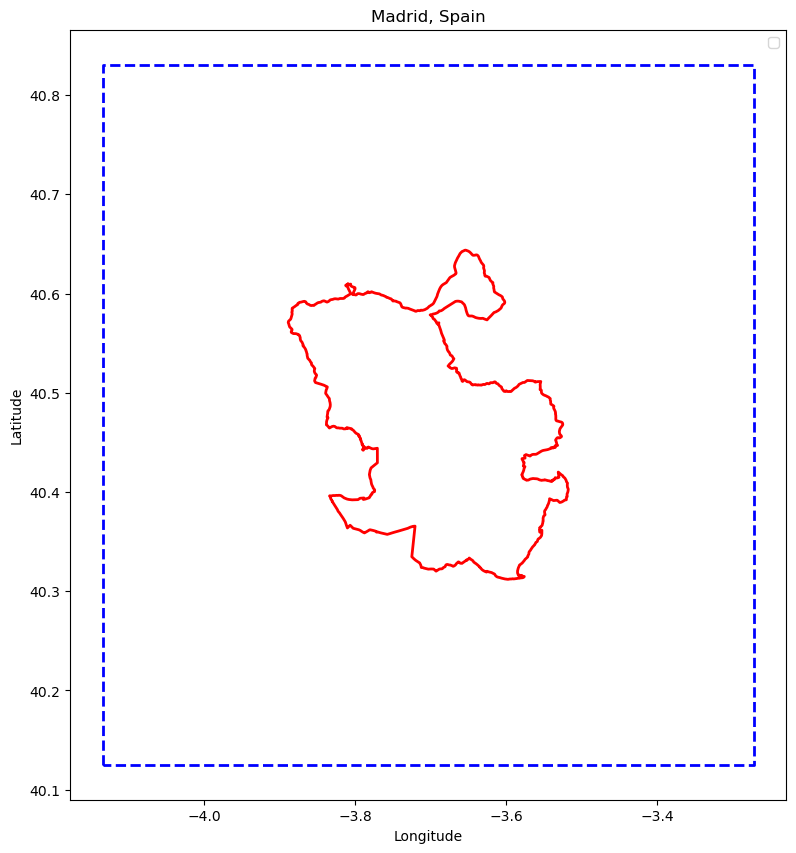

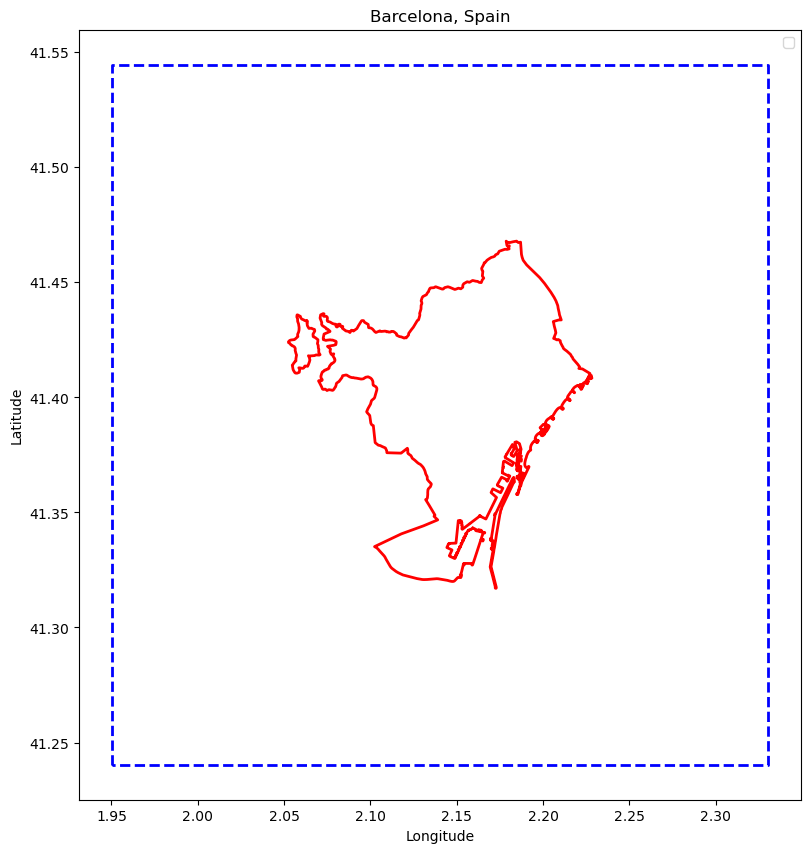

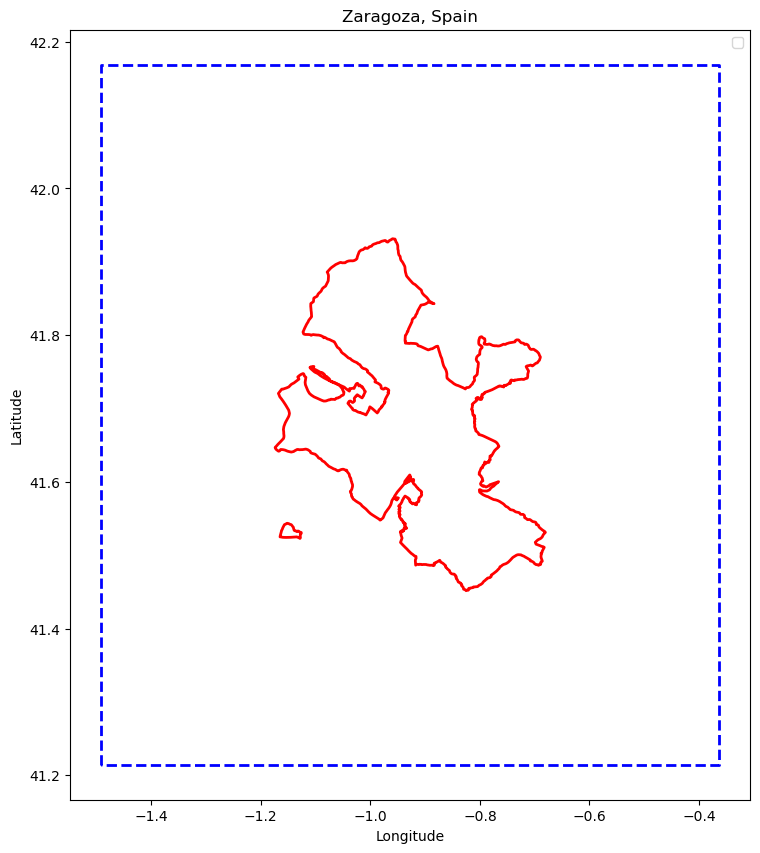

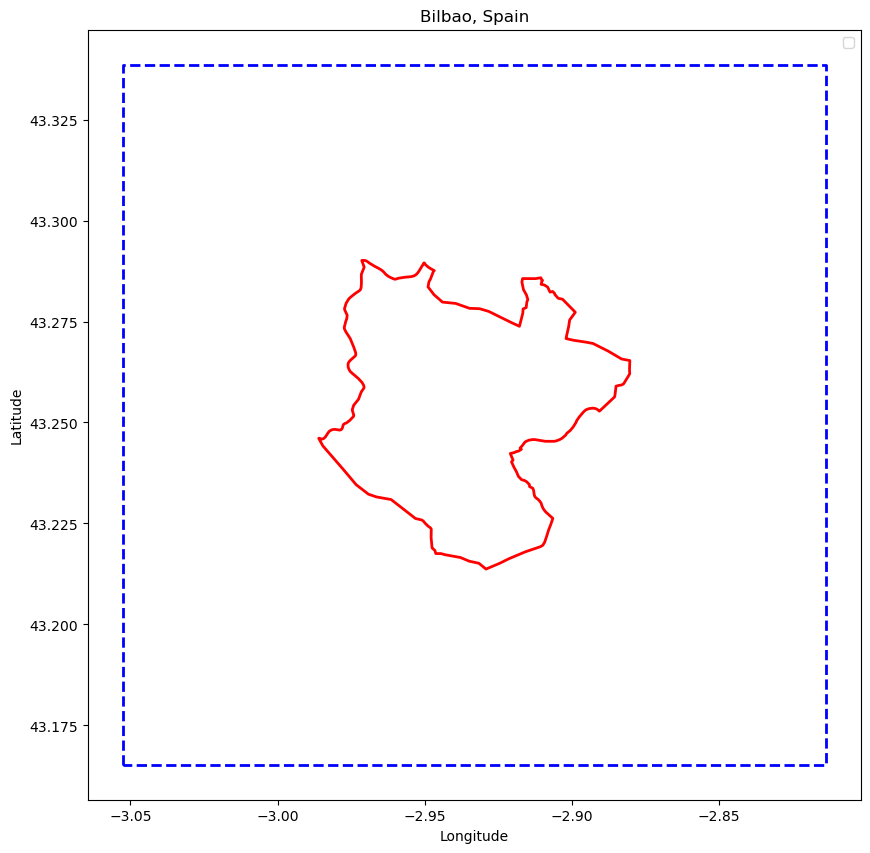

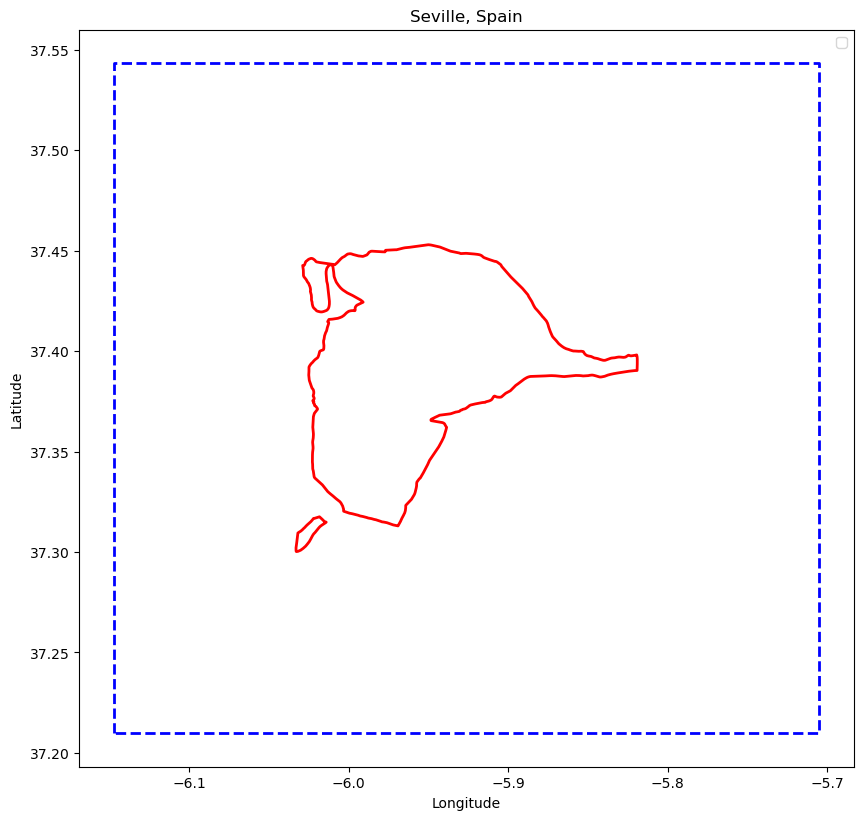

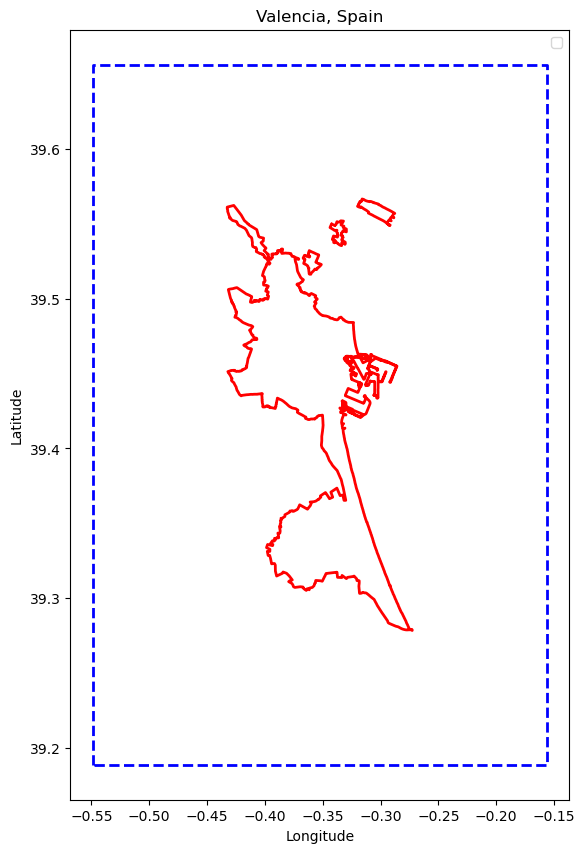

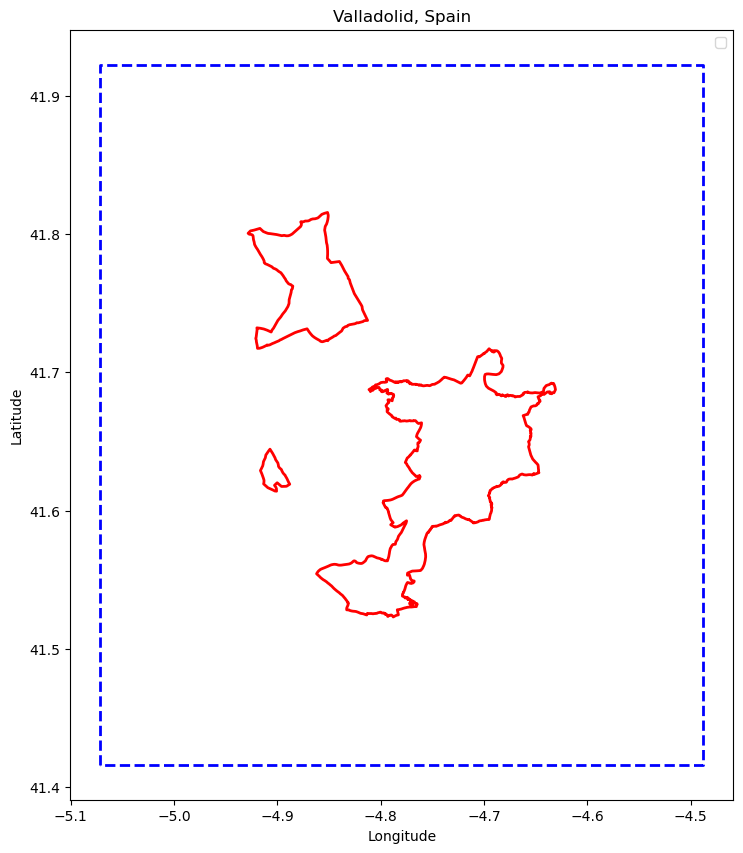

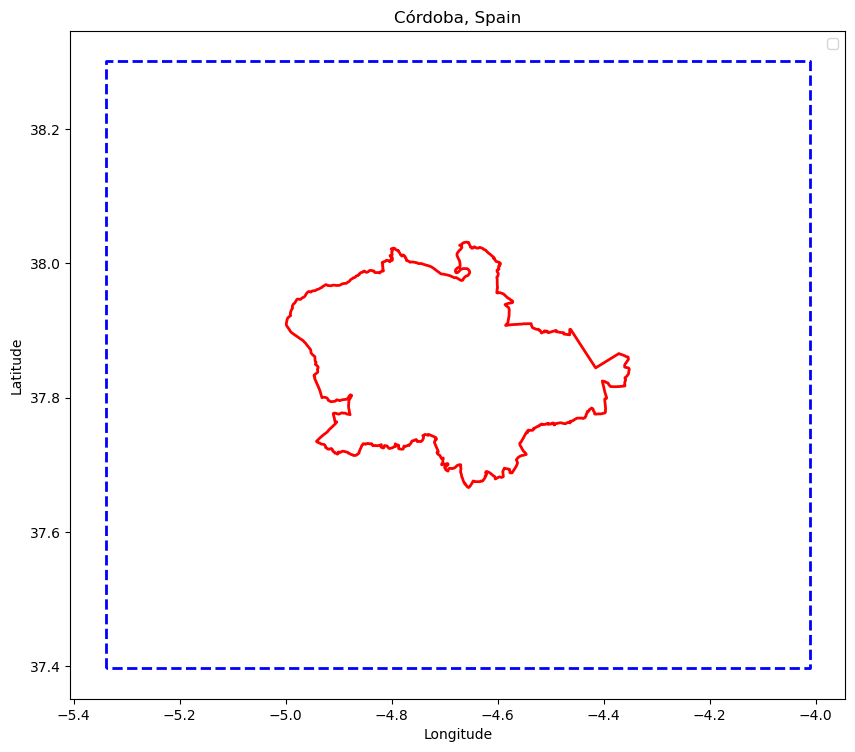

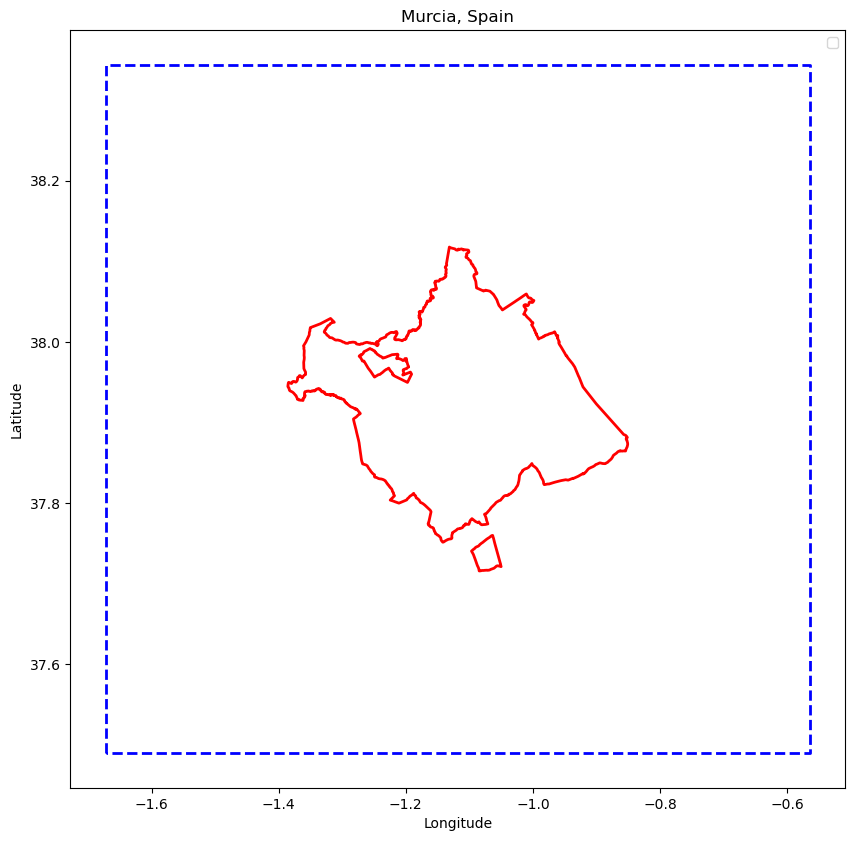

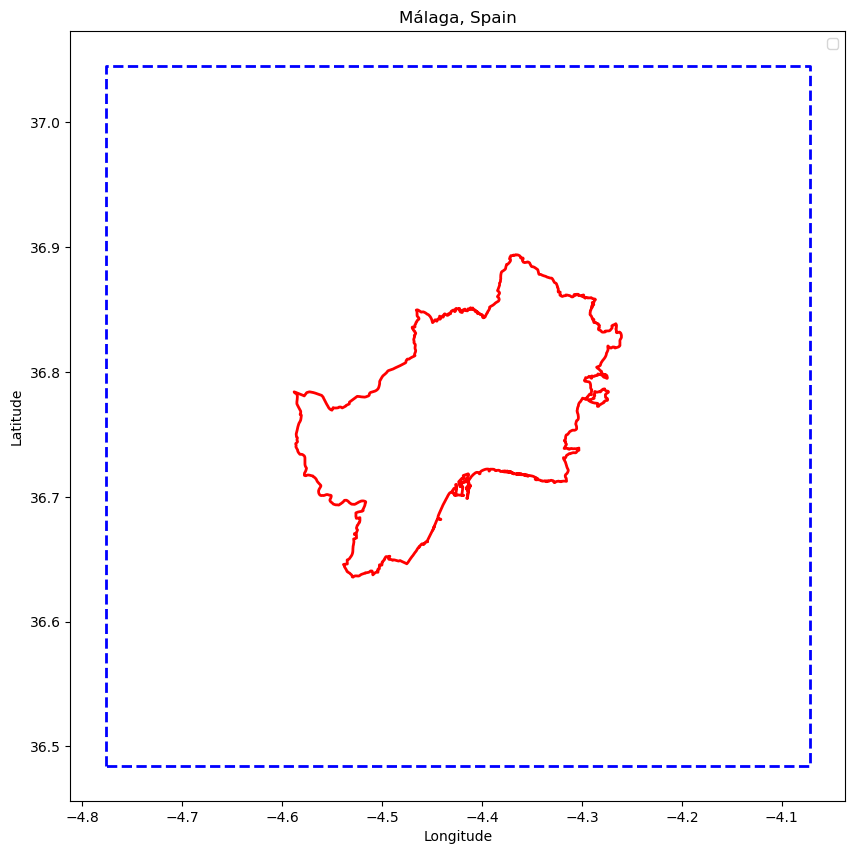

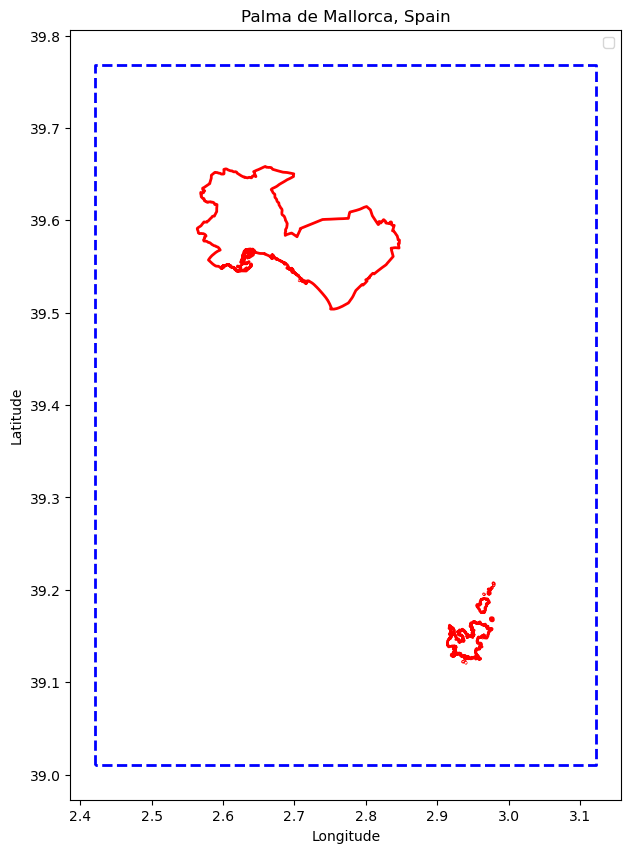

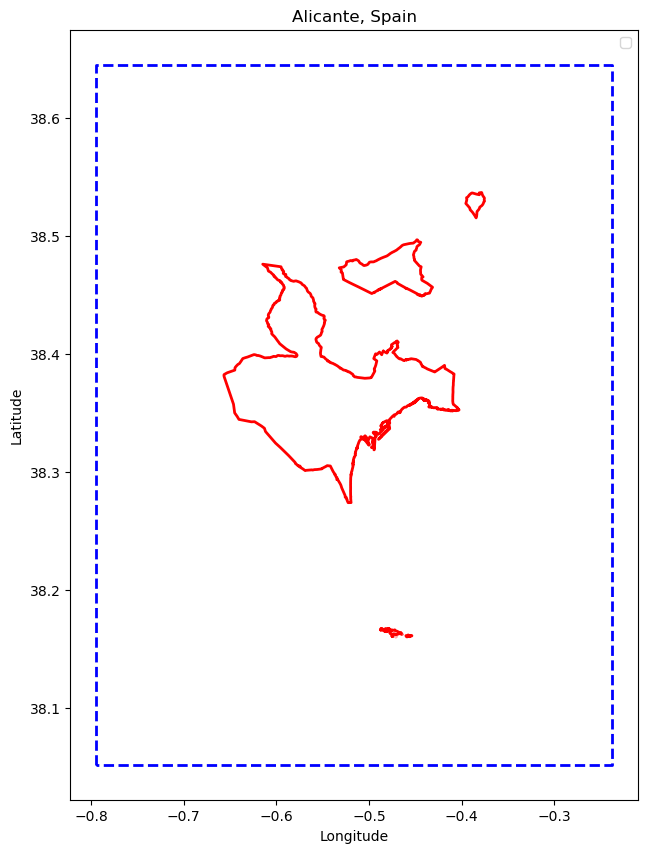

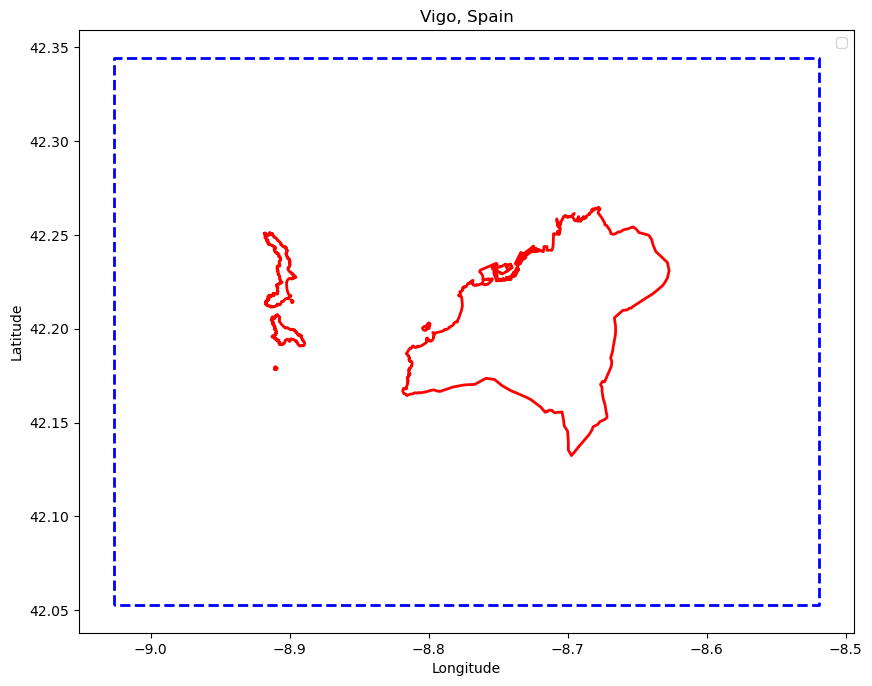

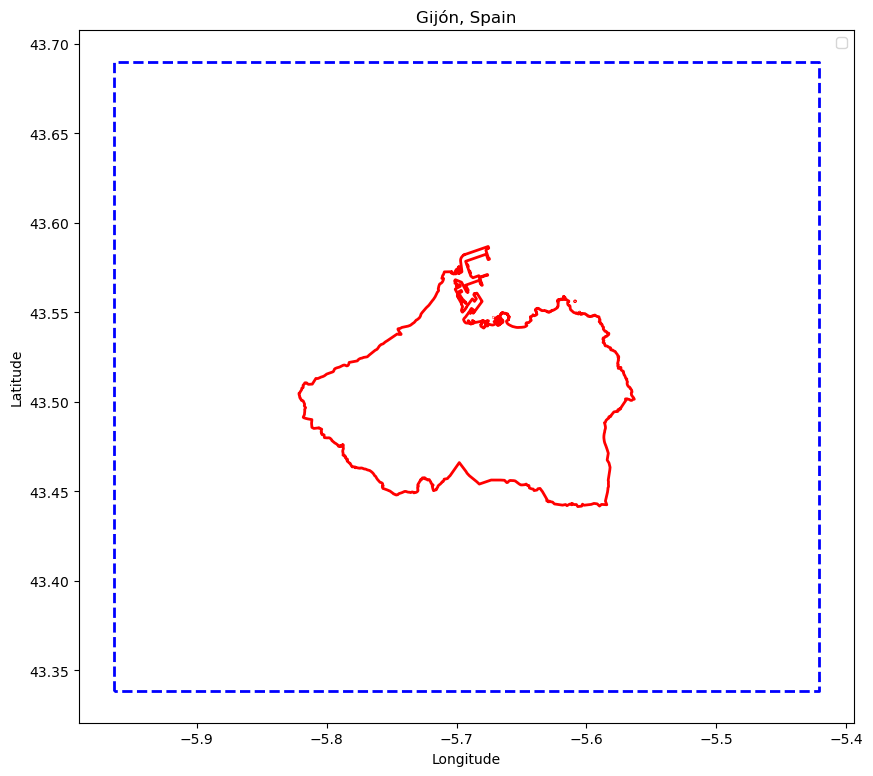

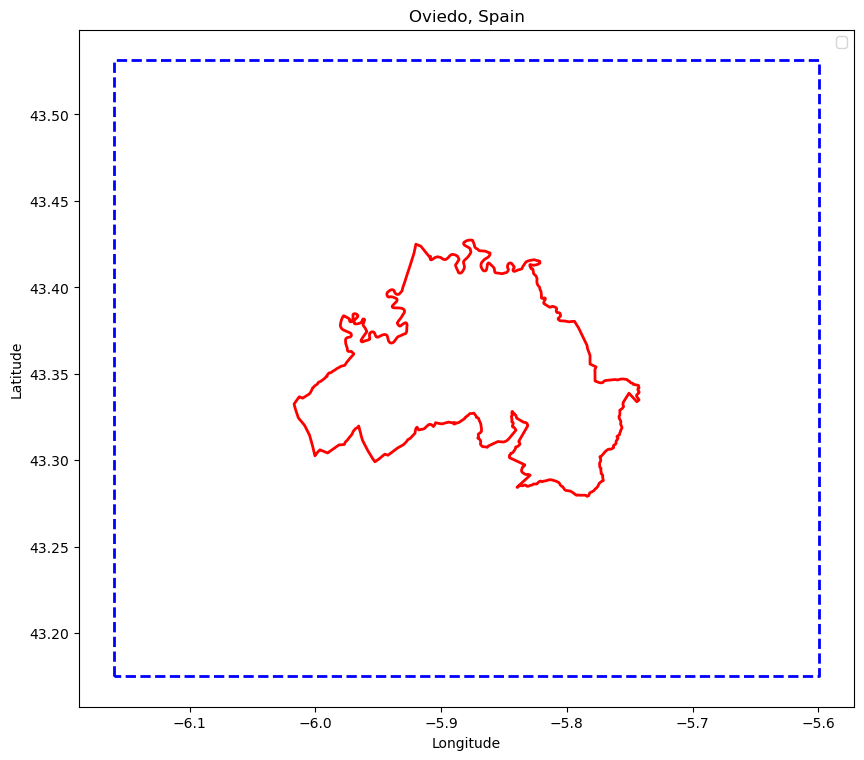

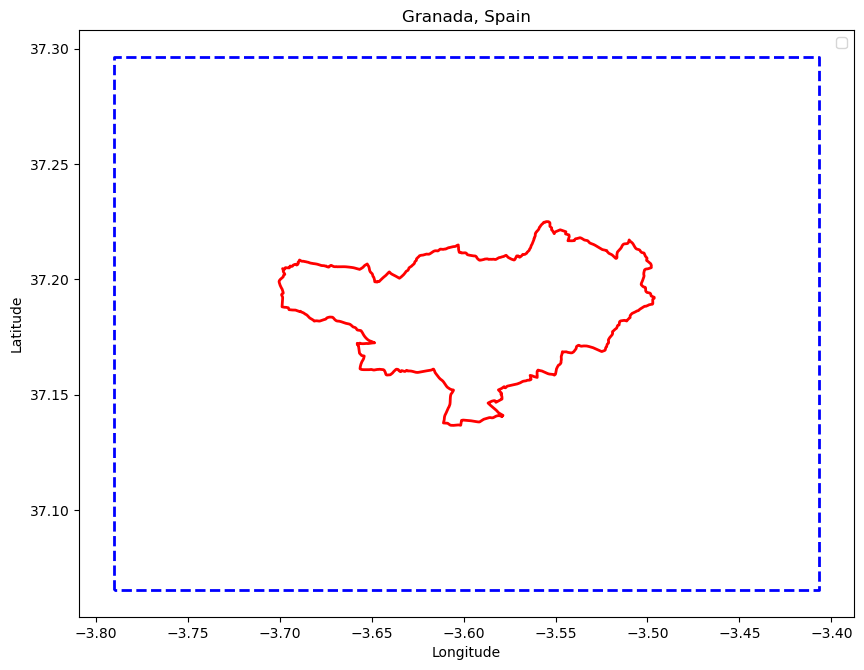

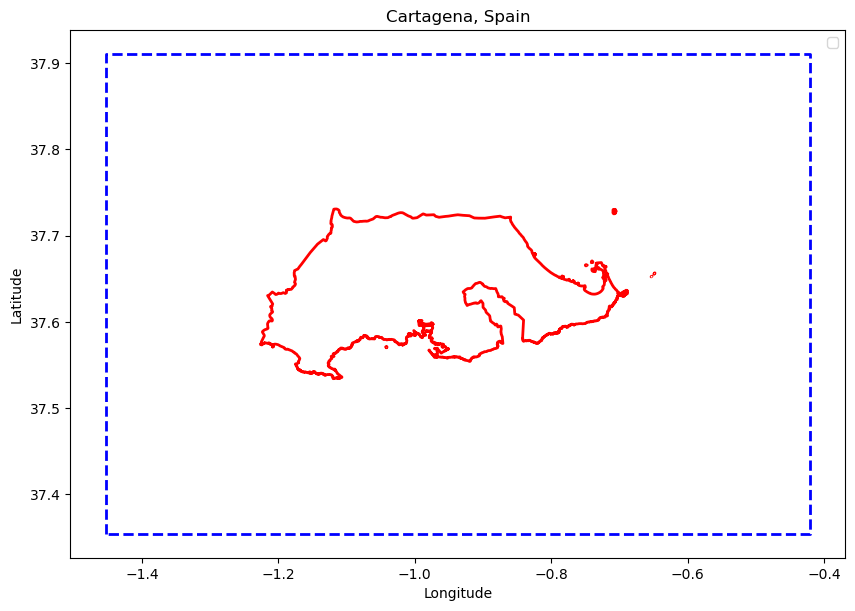

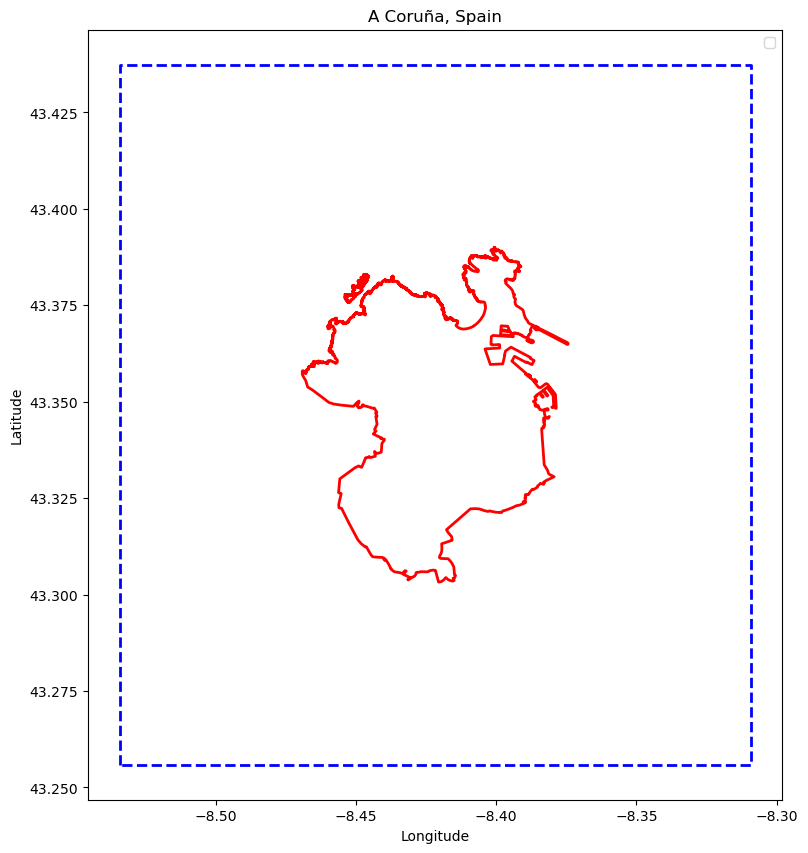

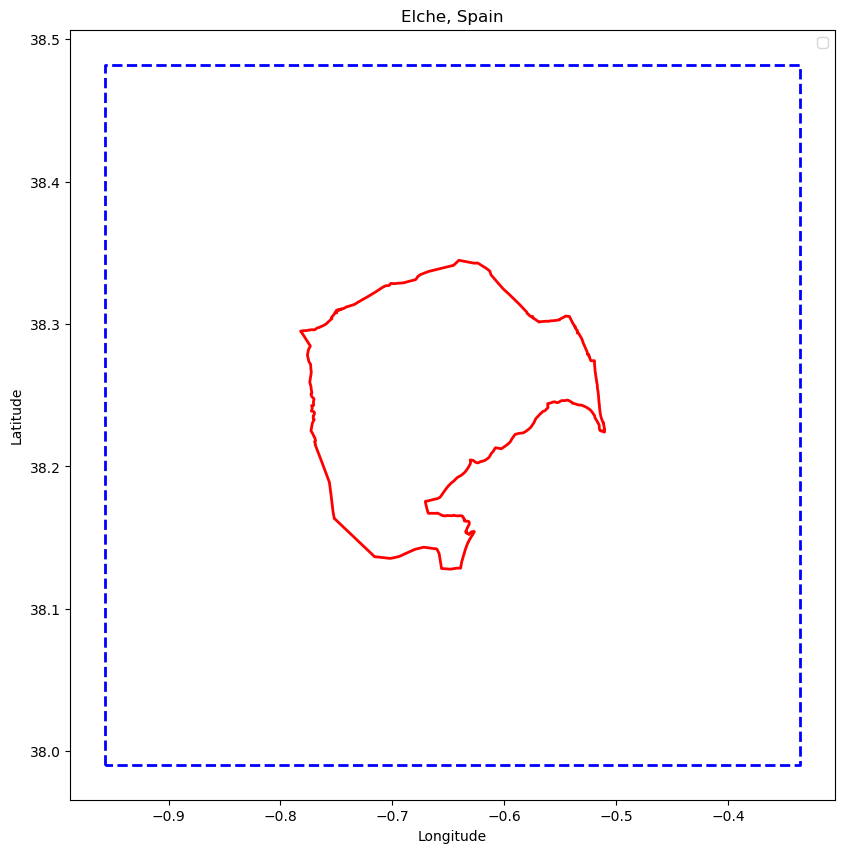

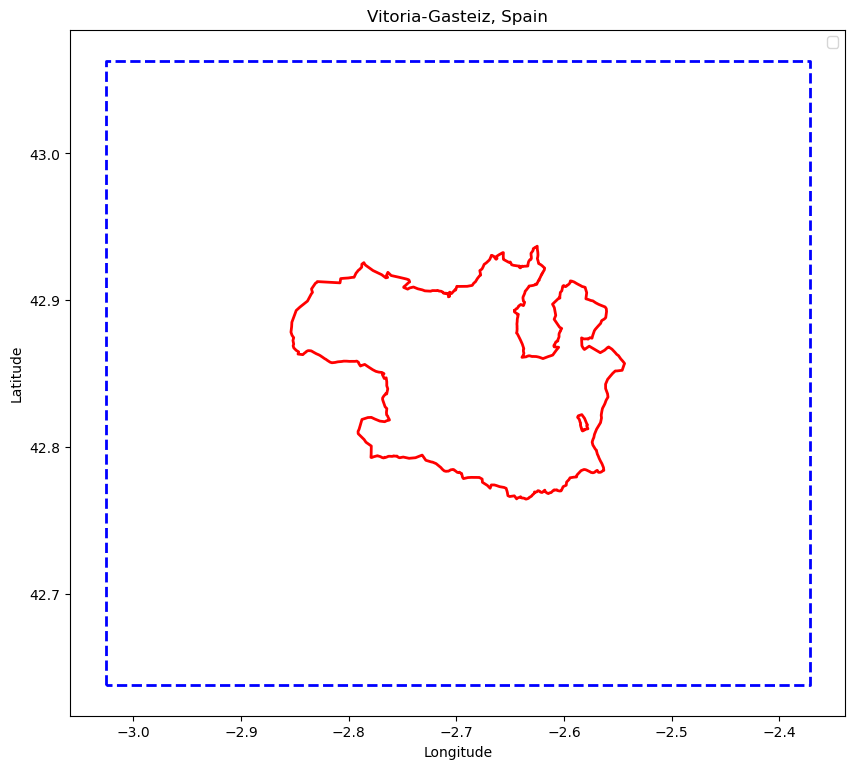

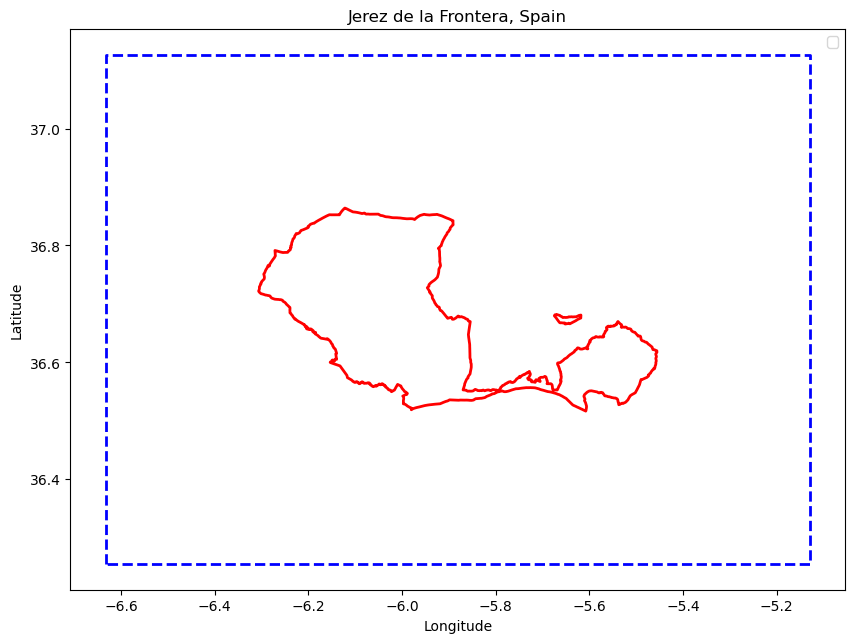

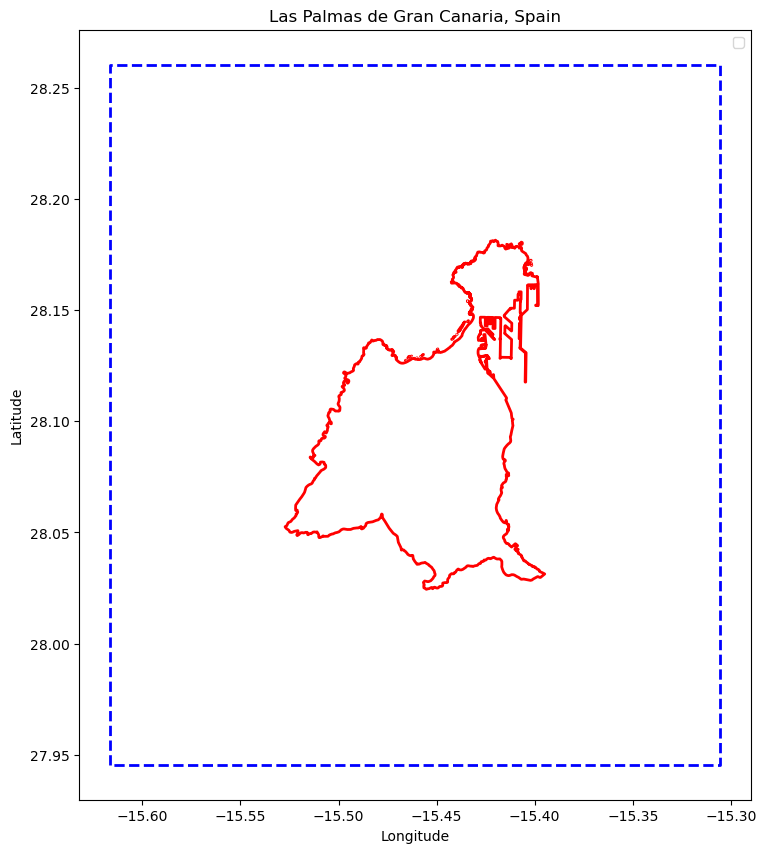

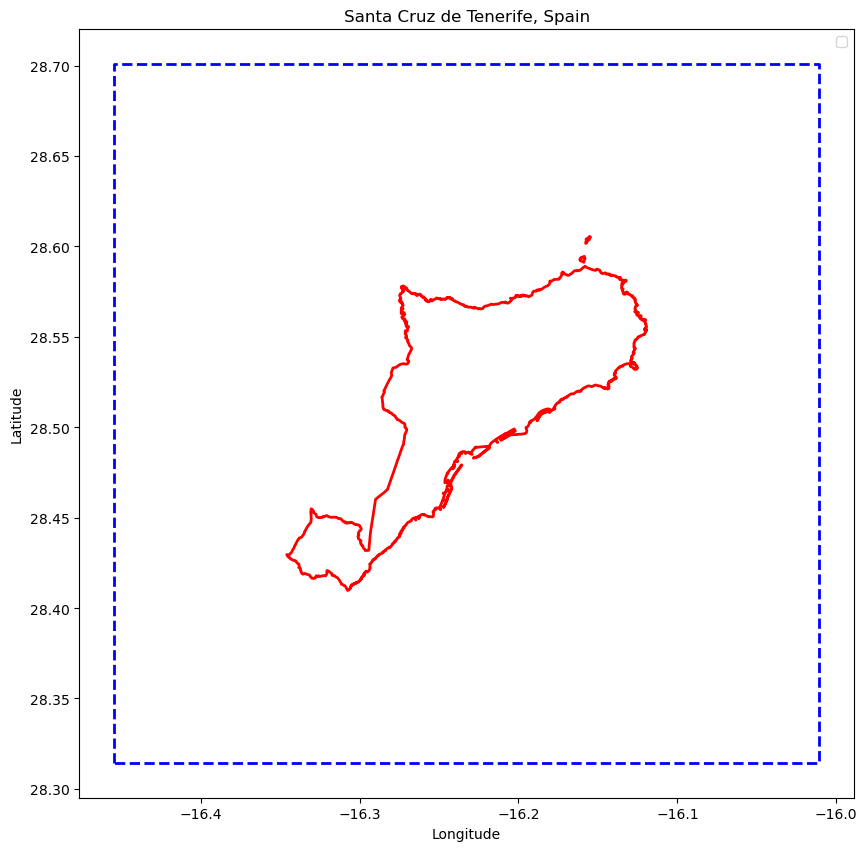

In [5]:
cities_box = {
    'Madrid': "Madrid, Spain",
    'Barcelona': "Barcelona, Spain",
    'Zaragoza': "Zaragoza, Spain",
    'Bilbao': "Bilbao, Spain",
    'Sevilla': "Seville, Spain",
    'Valencia': "Valencia, Spain",
    'Valladolid': "Valladolid, Spain",
    'Cordoba': "Córdoba, Spain",
    'Murcia': "Murcia, Spain",
    'Malaga': "Málaga, Spain",
    'Palma_de_Mallorca': "Palma de Mallorca, Spain",
    'Alicante': "Alicante, Spain",
    'Vigo': "Vigo, Spain",
    'Gijon': "Gijón, Spain",
    'Oviedo': "Oviedo, Spain",
    'Granada': "Granada, Spain",
    'Cartagena': "Cartagena, Spain",
    'A_Coruna': "A Coruña, Spain",
    'Elche': "Elche, Spain",
    'Vitoria_Gasteiz': "Vitoria-Gasteiz, Spain",
    'Jerez_de_la_Frontera': "Jerez de la Frontera, Spain",
    'Las_Palmas': "Las Palmas de Gran Canaria, Spain",
    'Santa_Cruz_de_Tenerife': "Santa Cruz de Tenerife, Spain"
}
    
    
xmin, xmax, ymin, ymax = {}, {}, {}, {}
extended_bbox_dict = {}

for city_key, city_full in cities_box.items():
    try:
        gdf = ox.geocode_to_gdf(city_full)
        poly = gdf.geometry.iloc[0]
        
        metr = gdf.to_crs(epsg=32630)
        metr_poly = metr.geometry.iloc[0]
        
        area_km2 = metr_poly.area / 1e6
        
        # multiply by a buffer factor
        buffer_factor = 1.5
        radius_km = math.sqrt(area_km2 / math.pi) * buffer_factor
        
        centroid = poly.centroid
        dlat = radius_km / 111.32
        dlon = radius_km / (111.32 * math.cos(math.radians(centroid.y)))
        
        minx, miny, maxx, maxy = poly.bounds
        xmin[city_key] = minx - dlon
        xmax[city_key] = maxx + dlon
        ymin[city_key] = miny - dlat
        ymax[city_key] = maxy + dlat
        
        ext = box(xmin[city_key], ymin[city_key], xmax[city_key], ymax[city_key])
        ext_bbox_gdf = gpd.GeoDataFrame({'geometry': [ext]}, crs=gdf.crs)
        extended_bbox_dict[city_key] = ext

        fig, ax = plt.subplots(figsize=(10, 10))
        gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Admin Boundary')
        ext_bbox_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linestyle='--', linewidth=2, label='Extended Bounding Box (+5km)')
        ax.set_title(city_full)  # or use city_key if you prefer
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend()
        plt.show()
        
    except Exception as e:
        print(f"Error with {city_full}: {e}")

# OPEN TEMPERATURE DATA

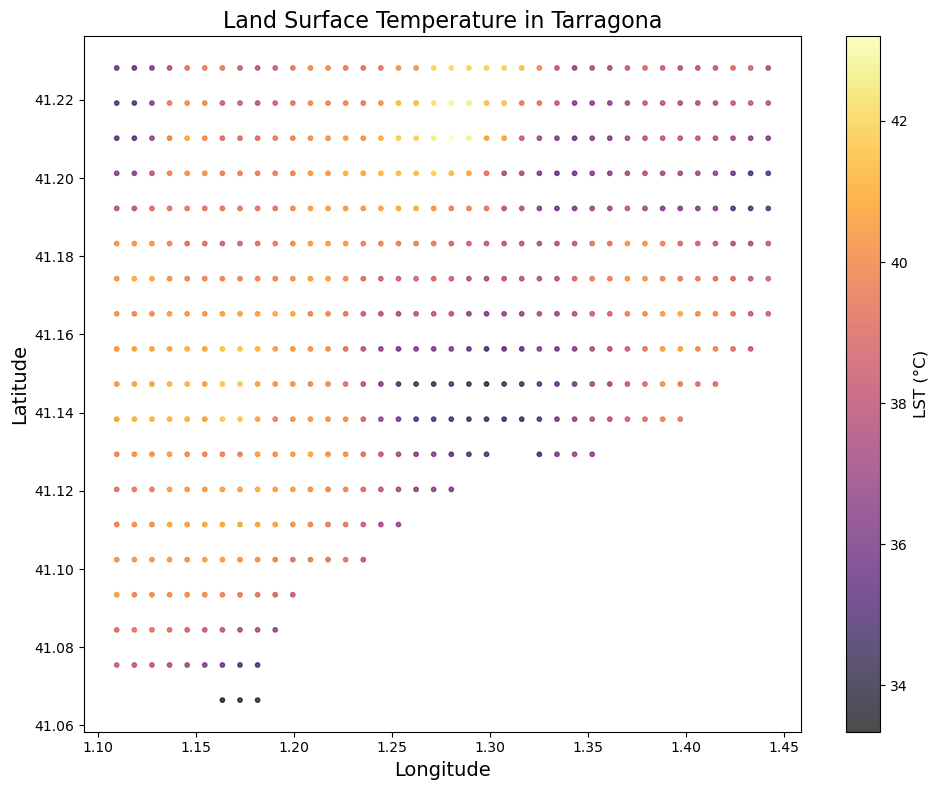

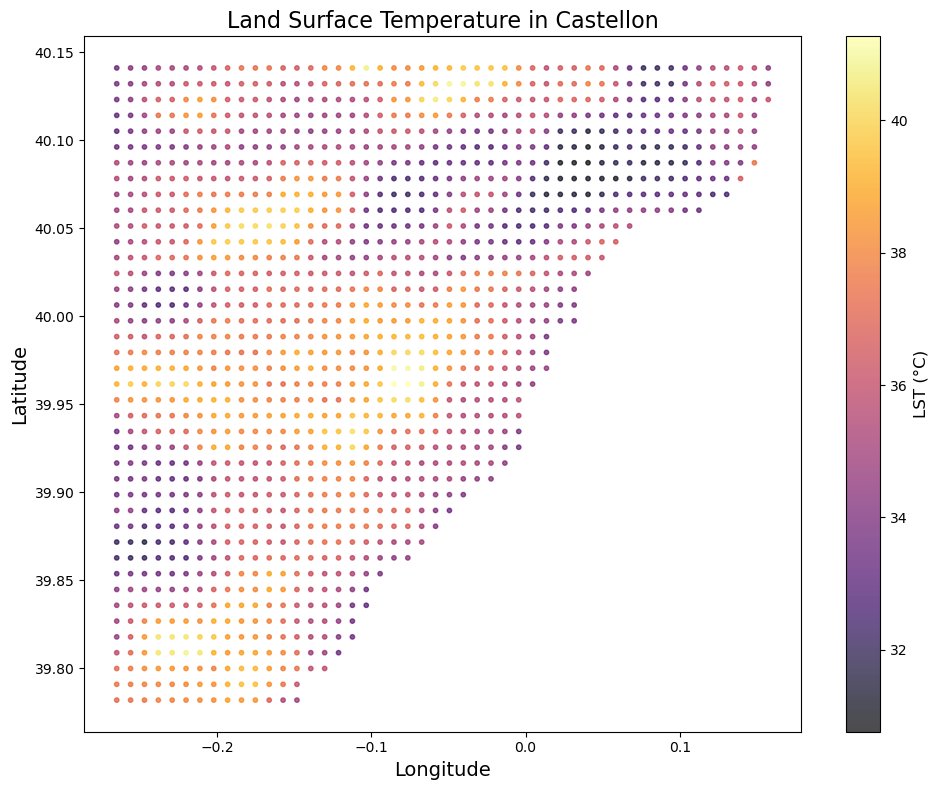

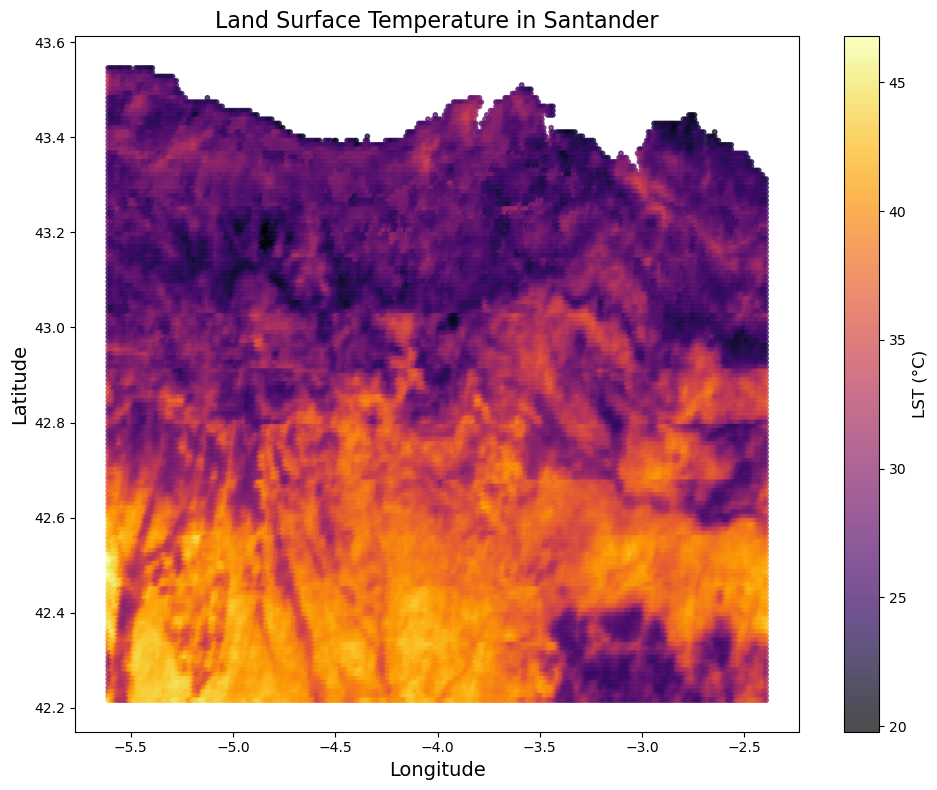

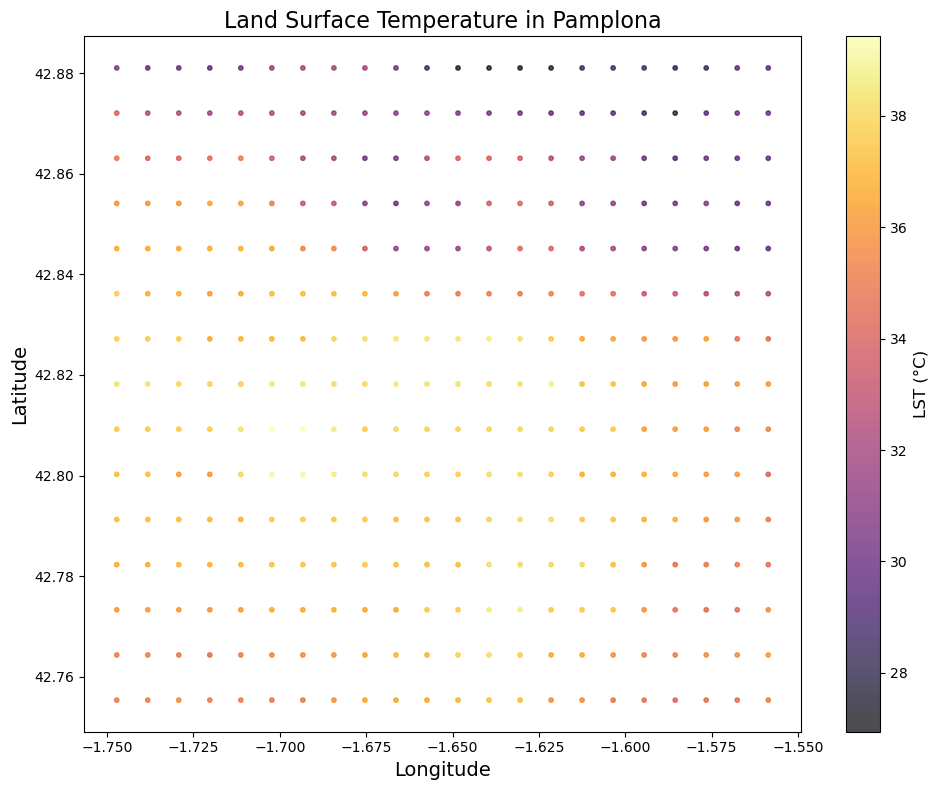

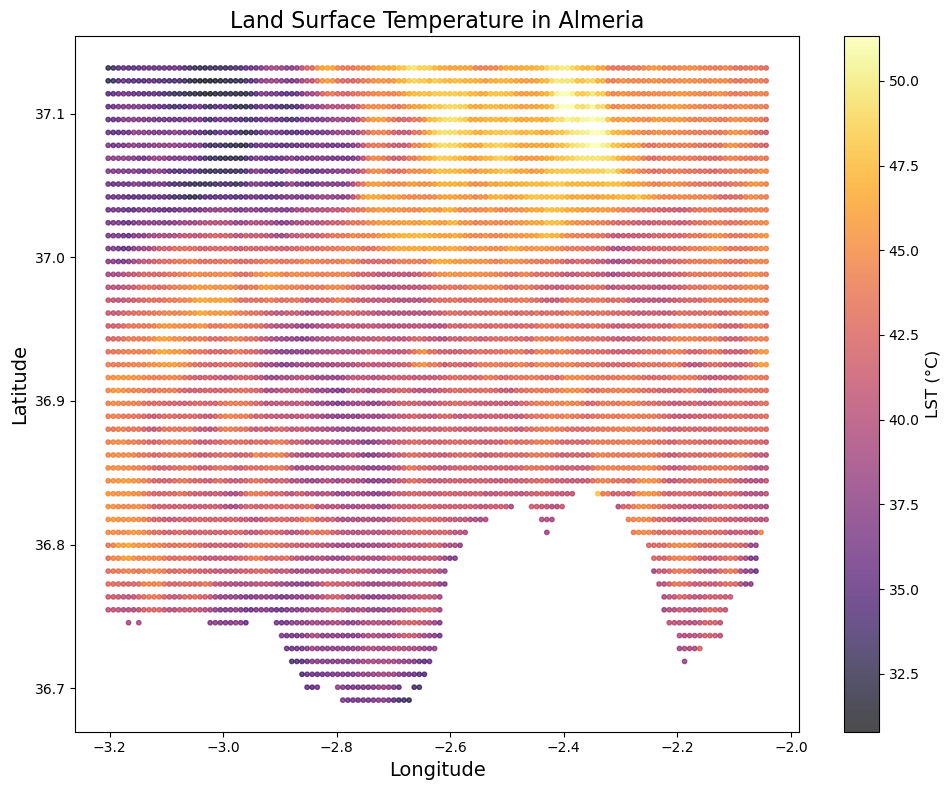

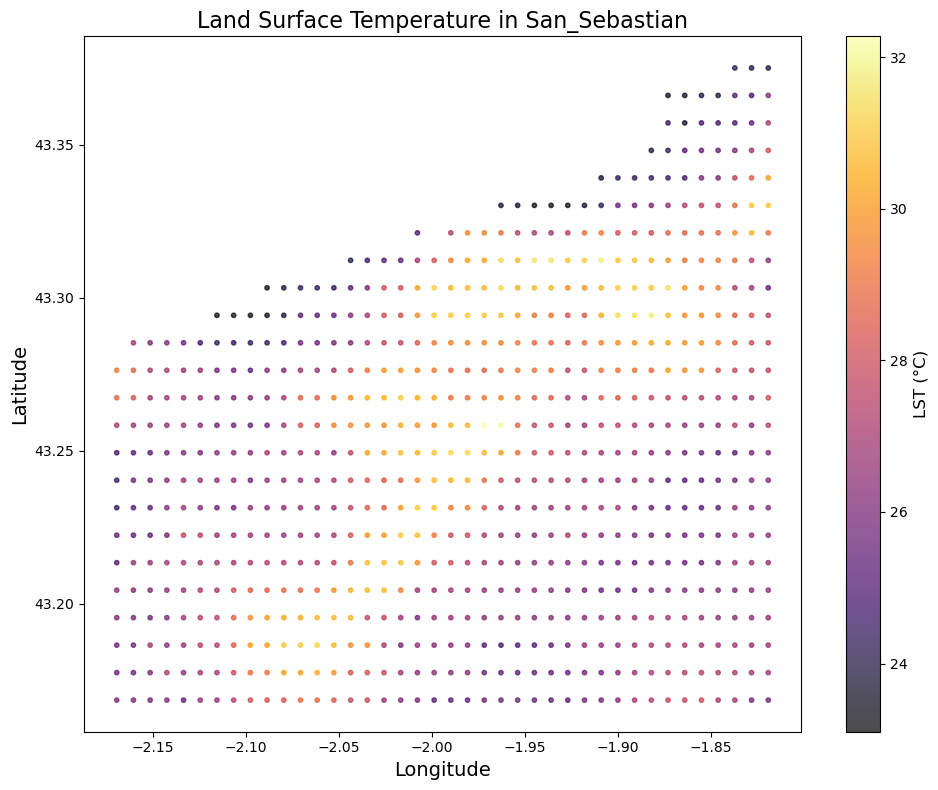

In [40]:
# os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA\temperature\LST_Aqua_daily')
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA\temperature')


file_path = 'LST_Aqua_2023_07_SpainCanaries.tif' #"LST_Aqua_2023_07_31_SpainCanaries_median.tif" 

# Abrir raster
with rasterio.open(file_path) as src:
    lst = src.read(1)
    transform = src.transform
    nodata = src.nodata

lst = np.where(lst == nodata, np.nan, lst)

# Función para convertir lon/lat a índices
def coord_to_index(x, y, transform):
    col, row = ~transform * (x, y)
    return int(row), int(col)

# Diccionario de DataFrames con puntos por ciudad
import pandas as pd
T_dic = {}

for city in xmin:
    row_min, col_min = coord_to_index(xmin[city], ymax[city], transform)
    row_max, col_max = coord_to_index(xmax[city], ymin[city], transform)

    sub_lst = lst[row_min:row_max, col_min:col_max]

    rows, cols = sub_lst.shape
    xs, ys = [], []
    temps = []

    for i in range(rows):
        for j in range(cols):
            val = sub_lst[i, j]
            if not np.isnan(val):
                x, y = transform * (col_min + j + 0.5, row_min + i + 0.5)
                xs.append(x)
                ys.append(y)
                temps.append(val)

    T_dic[city] = pd.DataFrame({'x': xs, 'y': ys, 'T': temps})

# === Plot tipo scatter como el ejemplo ===
for city, df in T_dic.items():
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        df['x'],
        df['y'],
        c=df['T'],
        cmap='inferno',
        s=10,
        alpha=0.7
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label('LST (°C)', fontsize=12)
    plt.title(f"Land Surface Temperature in {city}", fontsize=16)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.tight_layout()
    # plt.savefig(city + '_LST_Visualization_Map.png', dpi=600)
    plt.show()
    plt.close()

In [41]:
T_dic

{'Tarragona':             x          y       T
 0    1.109419  41.228180  35.375
 1    1.118403  41.228180  35.375
 2    1.127386  41.228180  36.125
 3    1.136369  41.228180  37.645
 4    1.145352  41.228180  39.245
 ..        ...        ...     ...
 515  1.172301  41.075466  34.795
 516  1.181285  41.075466  34.795
 517  1.163318  41.066483  33.340
 518  1.172301  41.066483  33.890
 519  1.181285  41.066483  33.890
 
 [520 rows x 3 columns],
 'Castellon':              x          y       T
 0    -0.265003  40.141218  33.460
 1    -0.256020  40.141218  34.175
 2    -0.247037  40.141218  34.525
 3    -0.238054  40.141218  35.045
 4    -0.229070  40.141218  35.045
 ...        ...        ...     ...
 1288 -0.184155  39.781892  38.390
 1289 -0.175171  39.781892  38.390
 1290 -0.166188  39.781892  36.820
 1291 -0.157205  39.781892  35.365
 1292 -0.148222  39.781892  34.945
 
 [1293 rows x 3 columns],
 'Santander':               x          y       T
 0     -5.609979  43.545833  23.845
 1    

# OPEN DISTRICTS DATA

In [42]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA\zonification')

# Districts geometries
cont = gpd.read_file('zonificacion_distritos.shp',encoding='utf-8',
                   dtype={'ID': str}, separator='|')

esp_ids = set(cont.ID.unique())

#filter shapefile, remove places abroad
cont = cont[cont.ID.isin(esp_ids)]     

In [43]:
cont

,ID,geometry
0,01001,"MULTIPOLYGON (((538090.184 4737372.731, 537856..."
1,01002,"MULTIPOLYGON (((501984.889 4753913.87, 501945...."
2,01004_AM,"MULTIPOLYGON (((488613.969 4778775.797, 488800..."
3,01009_AM,"POLYGON ((554658.552 4740793.546, 554617.177 4..."
4,01010,"POLYGON ((499938.436 4768365.76, 499305.175 47..."
...,...,...
3904,PT181,"MULTIPOLYGON (((-10344.118 4200097.99, -10107...."
3905,PT184,"POLYGON ((140218.189 4234650.534, 140627.814 4..."
3906,PT185,"POLYGON ((4481.172 4385435.009, 5048.847 43840..."
3907,PT186,"MULTIPOLYGON (((138162.872 4300415.413, 138043..."


In [44]:
# Take the center of the geometry as the district location
center = cont.copy()
center['geometry'] = center['geometry'].centroid

center['x'] = center['geometry'].x
center['y'] = center['geometry'].y

In [45]:
center

,ID,geometry,x,y
0,01001,POINT (539945.694 4741948.883),539945.693847,4.741949e+06
1,01002,POINT (502306.663 4763642.871),502306.663426,4.763643e+06
2,01004_AM,POINT (493797.446 4777478.589),493797.445729,4.777479e+06
3,01009_AM,POINT (546467.061 4747997.339),546467.060711,4.747997e+06
4,01010,POINT (493632.647 4769207.651),493632.646513,4.769208e+06
...,...,...,...,...
3904,PT181,POINT (12223.809 4219168.543),12223.809477,4.219169e+06
3905,PT184,POINT (76153.514 4202802.926),76153.513703,4.202803e+06
3906,PT185,POINT (14826.676 4344865.802),14826.676335,4.344866e+06
3907,PT186,POINT (100908.266 4348028.179),100908.266489,4.348028e+06


# COMBINE DISTRICTS and TEMPERTURE 

In [46]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

temperature_dfs = [df for df in T_dic.values()]
temperature_all = pd.concat(temperature_dfs, ignore_index=True)

print("Combined Temperature DataFrame:")
print(temperature_all.head())

geometry_temp = [Point(xy) for xy in zip(temperature_all['x'], temperature_all['y'])]

gdf_temp = gpd.GeoDataFrame(temperature_all, geometry=geometry_temp, crs='EPSG:4326')  # Assuming WGS84 CRS
print("\nTemperature GeoDataFrame CRS:", gdf_temp.crs)
print("First few entries of Temperature GeoDataFrame:")
print(gdf_temp.head())

if not isinstance(cont, gpd.GeoDataFrame):
    cont = gpd.GeoDataFrame(center, geometry='geometry')

print("\nDistricts GeoDataFrame CRS:", cont.crs)
print("First few entries of Districts GeoDataFrame:")
print(cont.head())

projected_crs = 'EPSG:25830'

cont_projected = cont.to_crs(projected_crs)

print("\nTransformed 'cont' GeoDataFrame to Projected CRS:", cont_projected.crs)

gdf_temp_projected = gdf_temp.to_crs(projected_crs)
print("\nTemperature GeoDataFrame Projected CRS:", gdf_temp_projected.crs)

try:
    gdf_temp_joined = gpd.sjoin(gdf_temp_projected, cont_projected[['ID', 'geometry']], how='left', predicate='within')
except AttributeError:
    gdf_temp_joined = gpd.sjoin(gdf_temp_projected, cont_projected[['ID', 'geometry']], how='left', op='within')

print("\nSpatial join completed for Temperature data. Number of joined records:", len(gdf_temp_joined))


Combined Temperature DataFrame:
          x         y       T
0  1.109419  41.22818  35.375
1  1.118403  41.22818  35.375
2  1.127386  41.22818  36.125
3  1.136369  41.22818  37.645
4  1.145352  41.22818  39.245

Temperature GeoDataFrame CRS: EPSG:4326
First few entries of Temperature GeoDataFrame:
          x         y       T                  geometry
0  1.109419  41.22818  35.375  POINT (1.10942 41.22818)
1  1.118403  41.22818  35.375   POINT (1.1184 41.22818)
2  1.127386  41.22818  36.125  POINT (1.12739 41.22818)
3  1.136369  41.22818  37.645  POINT (1.13637 41.22818)
4  1.145352  41.22818  39.245  POINT (1.14535 41.22818)

Districts GeoDataFrame CRS: EPSG:3042
First few entries of Districts GeoDataFrame:
         ID                                           geometry
0     01001  MULTIPOLYGON (((538090.184 4737372.731, 537856...
1     01002  MULTIPOLYGON (((501984.889 4753913.87, 501945....
2  01004_AM  MULTIPOLYGON (((488613.969 4778775.797, 488800...
3  01009_AM  POLYGON ((55465

In [47]:
# Compute average Temperature per district
avg_temp = gdf_temp_joined.groupby('ID')['T'].mean().reset_index().rename(columns={'T': 'avg_T'})
print("\nAverage Temperature per District:")
print(avg_temp.head())

cont_projected = cont_projected.merge(avg_temp, on='ID', how='left')

# Compute the number of measured temperature points per district
count_temp = gdf_temp_joined.groupby('ID').size().reset_index(name='temp_count')
cont_projected = cont_projected.merge(count_temp, on='ID', how='left')
cont_projected['temp_count'] = cont_projected['temp_count'].fillna(0)

cont_projected['area_sq_km'] = cont_projected.geometry.area / 1e6
cont_projected['temp_density_per_sq_km'] = cont_projected['temp_count'] / cont_projected['area_sq_km']

# Force districts with fewer than a minimum count to be treated as missing.
min_points_threshold = 1
cont_projected.loc[cont_projected['temp_count'] < min_points_threshold, 'avg_T'] = np.nan

# Interpolation
cont_projected['x'] = cont_projected.geometry.centroid.x
cont_projected['y'] = cont_projected.geometry.centroid.y

def idw_interpolation(target, known_coords, known_values, power=1):
    distances = np.sqrt(np.sum((known_coords - target)**2, axis=1))
    if np.any(distances == 0):
        return known_values[distances == 0][0]
    weights = 1 / distances**power
    return np.sum(weights * known_values) / np.sum(weights)

cont_projected['is_T_interpolated'] = False

for city in cities:
    print(f"\nProcessing city: {city}")
    city_bbox_deg = box(xmin[city], ymin[city], xmax[city], ymax[city])
    gdf_city_bbox = gpd.GeoDataFrame({'geometry': [city_bbox_deg]}, crs='EPSG:4326')
    
    city_bbox_projected = gdf_city_bbox.to_crs(cont_projected.crs)
    minx_proj, miny_proj, maxx_proj, maxy_proj = city_bbox_projected.total_bounds
    print(f"{city} bounding box in projected CRS: {city_bbox_projected.total_bounds}")
    
    cont_city = cont_projected[cont_projected.intersects(city_bbox_projected.iloc[0].geometry)].copy()
    print(f"Number of districts in {city}: {len(cont_city)}")

    mask_known_T = cont_city['avg_T'].notna()
    mask_missing_T = cont_city['avg_T'].isna()
    print("Districts with known Temp in city:", mask_known_T.sum())
    print("Districts missing Temp before interpolation in city:", mask_missing_T.sum())
    
    if mask_missing_T.sum() > 0:
        known_coords_T = cont_city.loc[mask_known_T, ['x', 'y']].values
        known_vals_T = cont_city.loc[mask_known_T, 'avg_T'].values
        
        for idx in cont_city.loc[mask_missing_T].index:
            target_point = np.array([cont_city.loc[idx, 'x'], cont_city.loc[idx, 'y']])
            interpolated_value = idw_interpolation(target_point, known_coords_T, known_vals_T, power=1)
            cont_city.loc[idx, 'avg_T'] = interpolated_value
            cont_city.loc[idx, 'is_T_interpolated'] = True
    print("Districts missing Temp after interpolation in city:", cont_city['avg_T'].isna().sum())
    
    cont_projected.loc[cont_city.index, 'avg_T'] = cont_city['avg_T']
    cont_projected.loc[cont_city.index, 'is_T_interpolated'] = cont_city['is_T_interpolated']
    
    interp_temp_city = cont_city[cont_city['is_T_interpolated'] == True]
    

print('10', cont_projected['is_T_interpolated'].unique())

print("Rows with is_T_interpolated == True:")
print(cont_projected[cont_projected['is_T_interpolated'] == True][
  ['ID', 'avg_T', 'temp_count', 'temp_density_per_sq_km', 'is_T_interpolated']].head(20))

print('11', cont_projected['is_T_interpolated'].unique())
result_with_data = cont_projected[cont_projected['temp_count'] > 0].copy()
result_no_data = cont_projected[cont_projected['temp_count'] == 0].copy()
print(f"\nNumber of Districts with Temperature Data: {len(result_with_data)}")
print(f"Number of Districts without Temperature Data: {len(result_no_data)}")

print('12', cont_projected['is_T_interpolated'].unique())
threshold_dynamic = result_with_data['temp_density_per_sq_km'].quantile(0.045)
print(f"\nSetting dynamic coverage threshold at the 5th percentile: {threshold_dynamic:.2f} points/sq.km")
selected_threshold = threshold_dynamic

print('13', cont_projected['is_T_interpolated'].unique())
filtered_districts = cont_projected[
    (cont_projected['temp_density_per_sq_km'] >= selected_threshold) |
    ((cont_projected['temp_density_per_sq_km'] == 0) & (cont_projected['is_T_interpolated'] == True))
].copy()

excluded_districts = cont_projected[
    (cont_projected['temp_density_per_sq_km'] < selected_threshold) &
    (cont_projected['is_T_interpolated'] == False)
].copy()

print(f"\nNumber of Districts Included (density >= {selected_threshold:.2f} or interpolated): {len(filtered_districts)}")
print(f"Number of Districts Excluded (density < {selected_threshold:.2f} and not interpolated): {len(excluded_districts)}")

print("\nFiltered GeoDataFrame with Average Temperature and PM:")
print(filtered_districts[['ID', 'avg_T', 'temp_count', 'area_sq_km', 'temp_density_per_sq_km', 'is_T_interpolated']].head())



Average Temperature per District:
         ID      avg_T
0     01001  32.397593
1     01002  28.320769
2  01004_AM  28.379978
3  01009_AM  29.939339
4     01010  29.488546

Processing city: Tarragona
Tarragona bounding box in projected CRS: [ 844488.6380366  4549156.31254029  874408.44489896 4573322.78118334]
Number of districts in Tarragona: 36
Districts with known Temp in city: 34
Districts missing Temp before interpolation in city: 2
Districts missing Temp after interpolation in city: 0

Processing city: Castellon
Castellon bounding box in projected CRS: [ 732626.1876438  4405802.38312662  825073.57787085 4450722.04117273]
Number of districts in Castellon: 47
Districts with known Temp in city: 45
Districts missing Temp before interpolation in city: 2
Districts missing Temp after interpolation in city: 0

Processing city: Santander
Santander bounding box in projected CRS: [ 284296.10970431 4672522.2995219   550474.88424159 4882803.05040845]
Number of districts in Santander: 323
Dist


Processing city: Tarragona


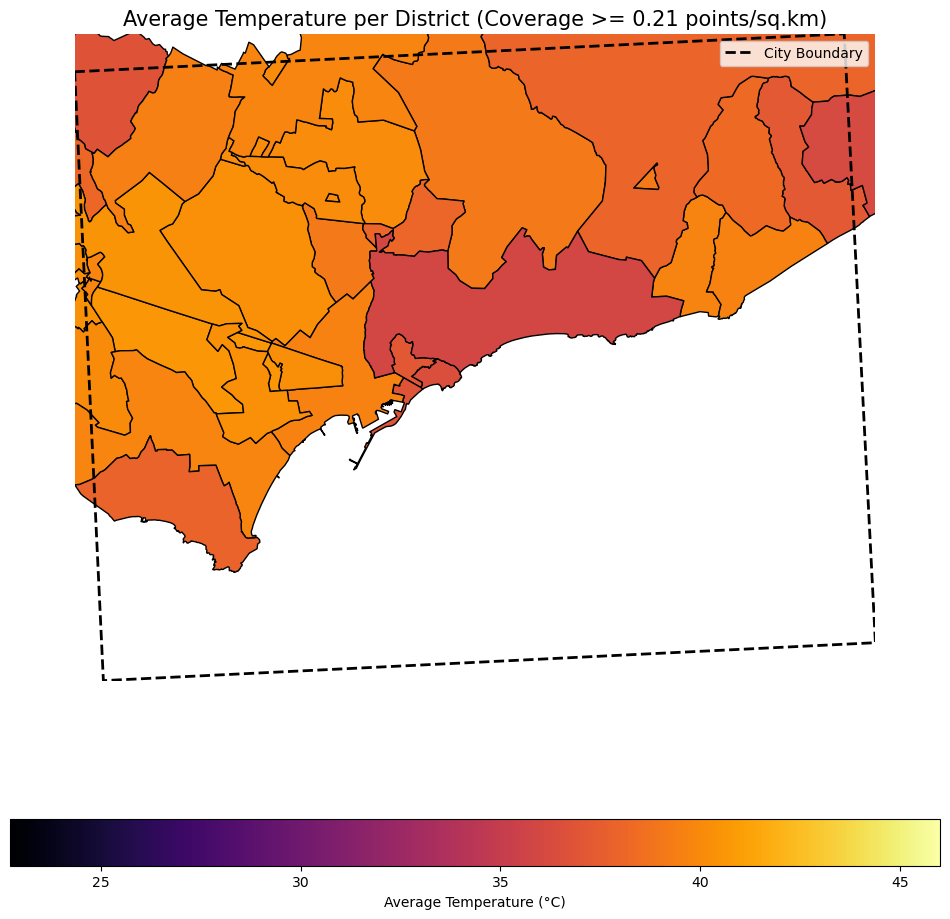


Processing city: Castellon


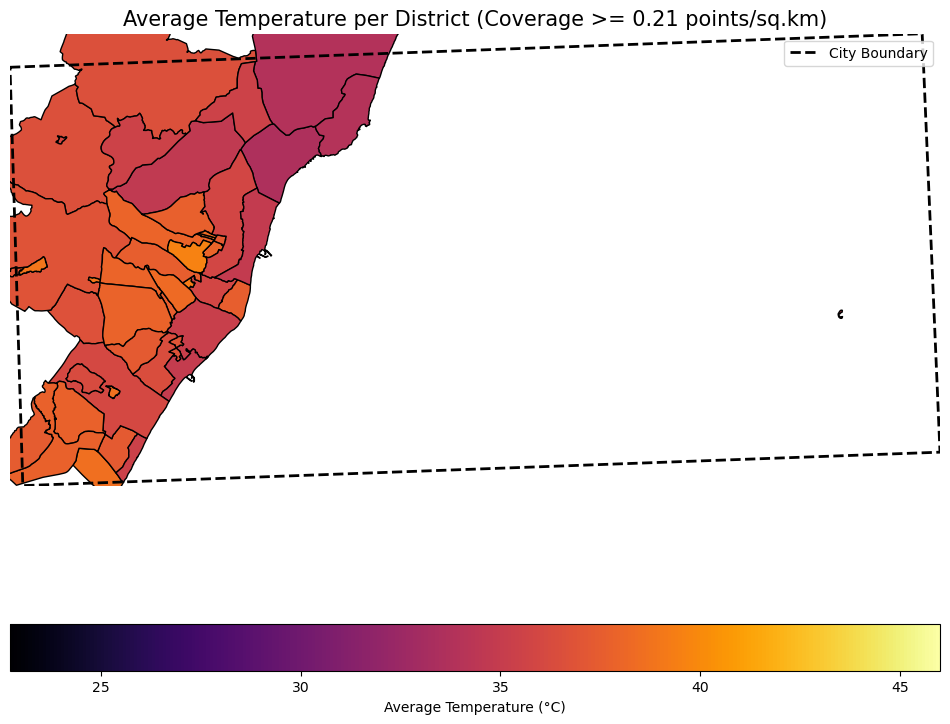


Processing city: Santander


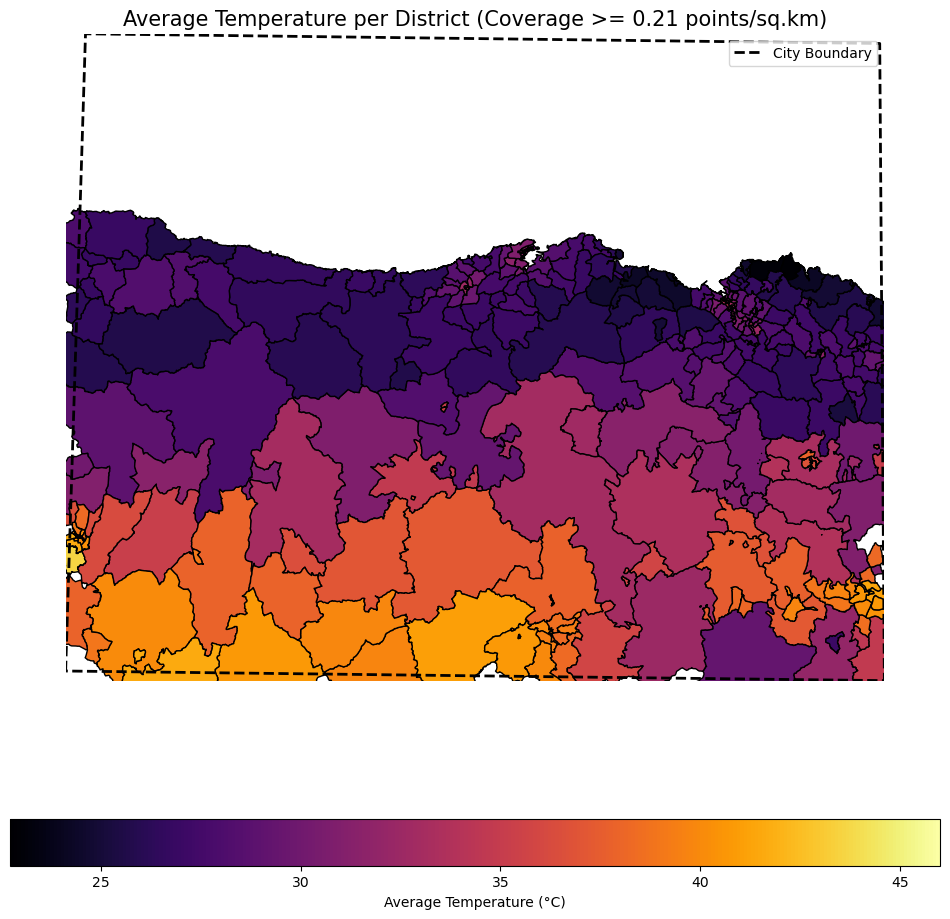


Processing city: Pamplona


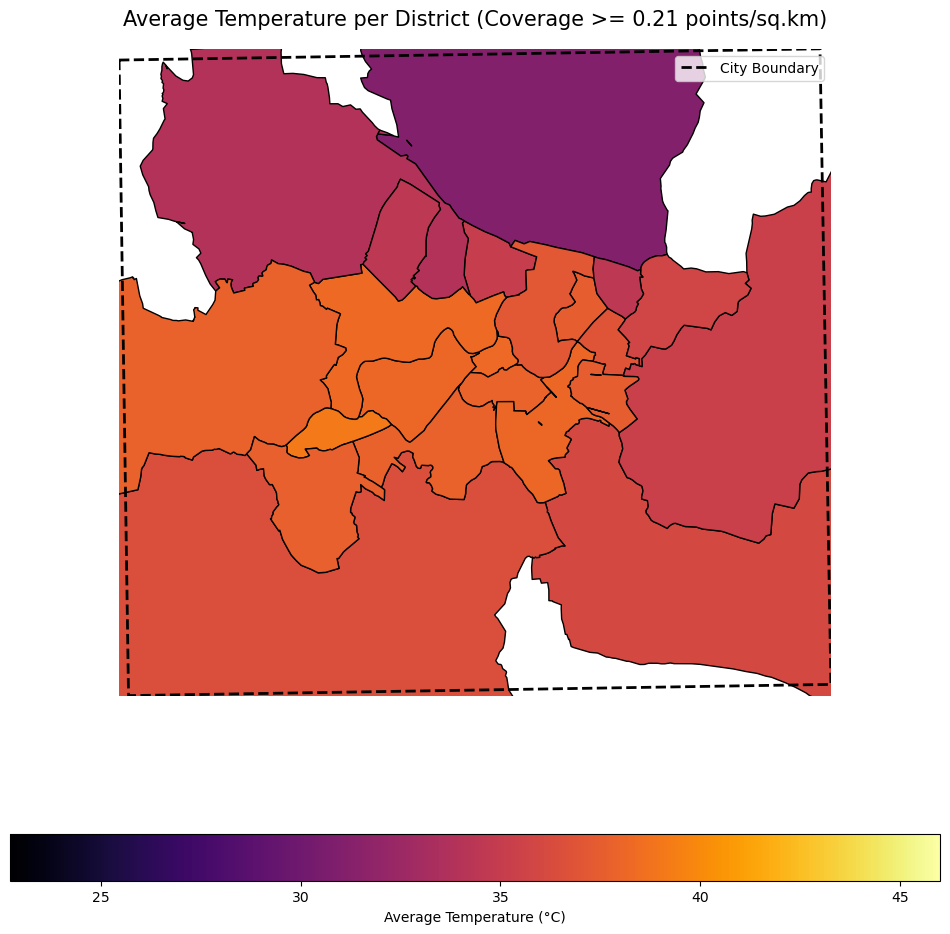


Processing city: Almeria


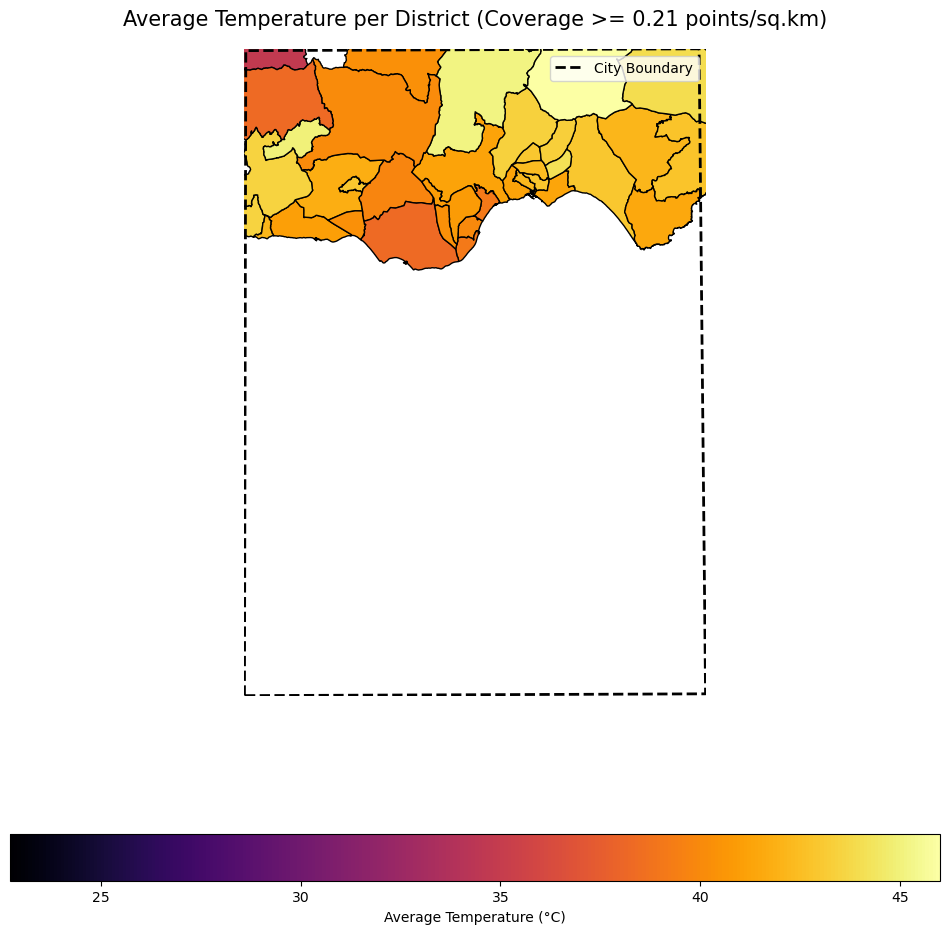


Processing city: San_Sebastian


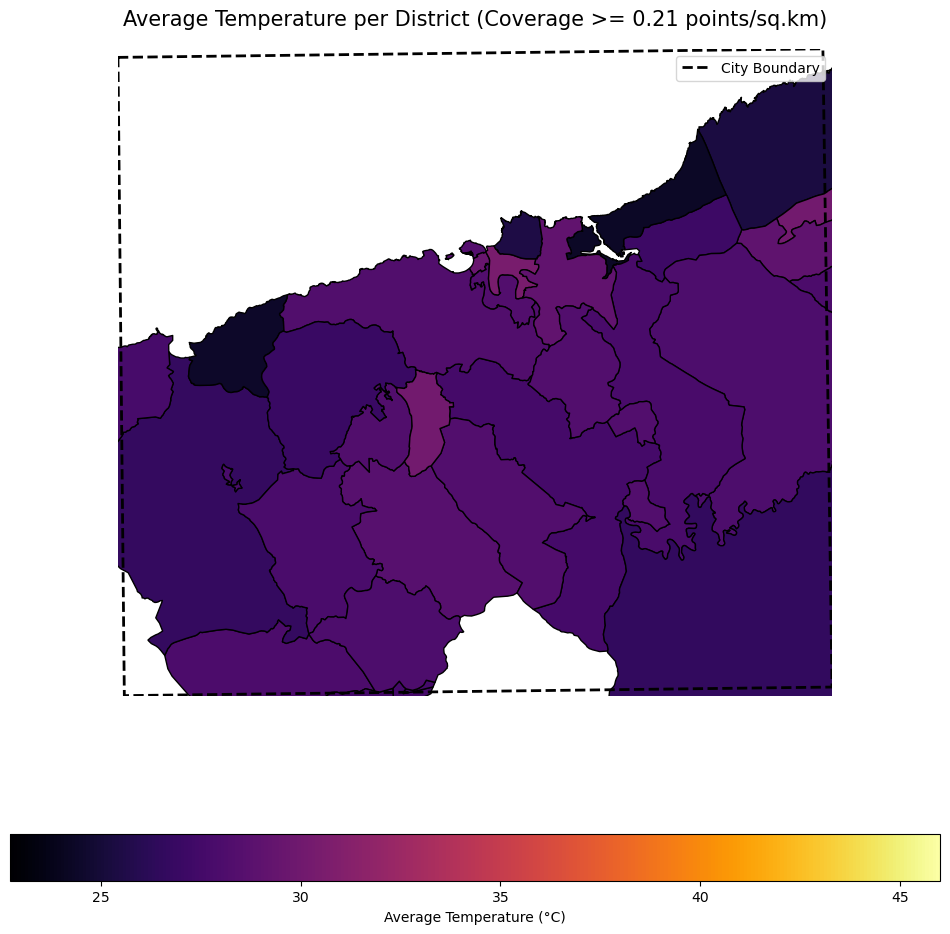

In [48]:
for city in cities:
    print(f"\nProcessing city: {city}")
    
    city_bbox_deg = box(xmin[city], ymin[city], xmax[city], ymax[city])
    gdf_city_bbox = gpd.GeoDataFrame({'geometry': [city_bbox_deg]}, crs='EPSG:4326')
    
    city_bbox_projected = gdf_city_bbox.to_crs(cont_projected.crs)
    minx_proj, miny_proj, maxx_proj, maxy_proj = city_bbox_projected.total_bounds

    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    filtered_districts.plot(
        column='avg_T',
        cmap='inferno',
        legend=True,
        ax=ax,
        edgecolor='black',
        legend_kwds={'label': "Average Temperature (°C)", 'orientation': "horizontal"}
    )
    city_bbox_projected.boundary.plot(ax=ax, color='black', linewidth=2, linestyle='--', label='City Boundary')
    
    ax.set_xlim(minx_proj, maxx_proj)
    ax.set_ylim(miny_proj, maxy_proj)
    
    plt.title(f'Average Temperature per District (Coverage >= {selected_threshold:.2f} points/sq.km)', fontsize=15)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.axis('off')  # Remove axis for better aesthetics
    plt.legend()
    plt.show()

# ASSIGN CITY TO EACH DISTRICT

In [49]:
filtered_result = filtered_districts.copy()

In [50]:
filtered_result

,ID,geometry,avg_T,temp_count,area_sq_km,temp_density_per_sq_km,x,y,is_T_interpolated
0,01001,"MULTIPOLYGON (((538090.184 4737372.731, 537856...",32.397593,27.0,19.922715,1.355237,539945.693847,4.741949e+06,False
1,01002,"MULTIPOLYGON (((501984.889 4753913.87, 501945....",28.320769,130.0,96.023174,1.353840,502306.663426,4.763643e+06,False
2,01004_AM,"MULTIPOLYGON (((488613.969 4778775.797, 488800...",28.379978,77.0,57.809391,1.331964,493797.445729,4.777479e+06,False
3,01009_AM,"POLYGON ((554658.552 4740793.546, 554617.177 4...",29.939339,310.0,338.757136,0.915110,546467.060711,4.747997e+06,False
4,01010,"POLYGON ((499938.436 4768365.76, 499305.175 47...",29.488546,196.0,140.854288,1.391509,493632.646513,4.769208e+06,False
...,...,...,...,...,...,...,...,...,...
3693,48905,"MULTIPOLYGON (((507449.211 4792124.026, 507342...",29.065200,25.0,18.087128,1.382198,510897.607580,4.792970e+06,False
3694,48906_AM,"POLYGON ((532102.784 4795421.318, 532075.16 47...",24.842436,117.0,88.615144,1.320316,532354.378859,4.799181e+06,False
3695,48910_AM,"POLYGON ((529733.162 4780319.88, 529723.037 47...",27.267123,95.0,68.535956,1.386134,526250.507814,4.787482e+06,False
3696,48912_AM,"MULTIPOLYGON (((493795.78 4777120.265, 493663....",27.382216,85.0,61.084116,1.391524,495968.942921,4.782036e+06,False


In [51]:
# Assign Each District to the Nearest City

# Define city centers
city_coords = {}

for city in T_dic.keys():
    if city in T_dic:
        city_coords[city] = (T_dic[city]['x'].mean(), T_dic[city]['y'].mean())
    else:
        print(f"Warning: {city} not found in T_dic.")

cities_df = pd.DataFrame({
    'city': list(city_coords.keys()),
    'x': [coord[0] for coord in city_coords.values()],
    'y': [coord[1] for coord in city_coords.values()]
})

cities_geometry = [Point(xy) for xy in zip(cities_df['x'], cities_df['y'])]

gdf_cities = gpd.GeoDataFrame(cities_df, geometry=cities_geometry, crs='EPSG:4326')  # crs = 'EPSG:3042' if needed

gdf_cities = gdf_cities.to_crs(filtered_districts.crs)

print("\nCity Centers GeoDataFrame:")
print(gdf_cities)

gdf_cities_unique = gdf_cities.drop_duplicates(subset='city')

try:
    filtered_districts = gpd.sjoin_nearest(
        filtered_districts,
        gdf_cities_unique[['city', 'geometry']],
        how='left',
        distance_col='distance'
    )
except AttributeError:
    print("GeoPandas version <0.10.0 detected. Using an alternative approach for nearest join.")
    from shapely.ops import nearest_points

    def nearest_city(row, cities_gdf):
        nearest_geom = cities_gdf.geometry.distance(row.geometry.centroid).idxmin()
        return cities_gdf.loc[nearest_geom, 'city']

    filtered_districts['city'] = filtered_districts.apply(lambda row: nearest_city(row, gdf_cities_unique), axis=1)

if 'city_right' in filtered_districts.columns:
    filtered_districts = filtered_districts.rename(columns={'city_right': 'city'})

print("\nFiltered Districts GeoDataFrame with Assigned Cities:")
print(filtered_districts[['ID', 'city']].head())


City Centers GeoDataFrame:
            city         x          y                        geometry
0      Tarragona  1.253392  41.167820   POINT (856852.07 4566114.693)
1      Castellon -0.111803  39.996932  POINT (746565.004 4431412.922)
2      Santander -4.028425  42.825298  POINT (415937.307 4741927.619)
3       Pamplona -1.652900  42.818198  POINT (610123.846 4741506.294)
4        Almeria -2.640324  36.944465  POINT (532025.868 4088772.098)
5  San_Sebastian -1.976753  43.247776  POINT (583067.565 4788838.781)

Filtered Districts GeoDataFrame with Assigned Cities:
         ID           city
0     01001  San_Sebastian
1     01002  San_Sebastian
2  01004_AM      Santander
3  01009_AM  San_Sebastian
4     01010      Santander


# SEPARATE DATA PER CITIES

In [52]:
city_results = {}

for city in cities:
    city_gdf = filtered_districts[filtered_districts['city'] == city].copy()
    
    if 'distance' in city_gdf.columns:
        city_gdf = city_gdf.drop(columns=['distance'])
    
    city_results[city] = city_gdf
    
    print(f"City: {city}, Number of Districts: {len(city_gdf)}")

City: Tarragona, Number of Districts: 34
City: Castellon, Number of Districts: 43
City: Santander, Number of Districts: 169
City: Pamplona, Number of Districts: 44
City: Almeria, Number of Districts: 38
City: San_Sebastian, Number of Districts: 154


# OPEN POPULATION DATA per DISTRICT

In [53]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA')

pop = pd.read_csv('population/poblacion_distritos.csv', delimiter='|',header=None)
pop.rename(columns={0:'district',1:'population'},inplace=True)
pop = pop[pop.district.isin(esp_ids)]
pop = pop[~pd.isna(pop.population)]
pop_dict = dict(zip(pop.district,pop.population))

In [54]:
pop_df = pd.DataFrame(list(pop_dict.items()), columns=['ID', 'population'])

In [55]:
pop_df

,ID,population
0,01001,2925.0
1,01002,10307.0
2,01004_AM,3005.0
3,01009_AM,4599.0
4,01010,2951.0
...,...,...
3738,5200104,9100.0
3739,5200105,15717.0
3740,5200106,5718.0
3741,5200107,14067.0


# Median income per consumption unit of districts

https://www.ine.es/dynt3/inebase/index.htm?padre=5650&capsel=5650#

In [56]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA')

renta_pp = pd.read_csv('renta/30824.csv', delimiter=';', encoding='utf-8')
renta_pp = renta_pp[~pd.isna(renta_pp.Distritos)]
renta_pp = renta_pp[renta_pp.Periodo==2022]
#median is more informative than mean, median revenue per unity of consommation ~ household size
renta_pp = renta_pp[renta_pp['Indicadores de renta media']=='Mediana de la renta por unidad de consumo']
#remove sections, smaller areas
renta_pp = renta_pp[pd.isna(renta_pp.Secciones)]
#get the code of district
renta_pp['dist_code'] = renta_pp['Distritos'].apply(lambda x: x.split(' ')[0])
#remove the other columns
renta_pp = renta_pp[['dist_code','Total']]
#remove anonymized entries
renta_pp = renta_pp[renta_pp.Total!='.']
renta_pp.Total = renta_pp.Total.astype('float')
#remove NaN that correspond to places abroad
renta_pp = renta_pp[~pd.isna(renta_pp.Total)]

In [57]:
renta_pp

,dist_code,Total
72,0100101,20.65
264,0100201,22.05
696,0100301,26.95
840,0100401,20.65
984,0100601,22.05
...,...,...
2668920,5200104,10.15
2669160,5200105,9.45
2669592,5200106,22.75
2669784,5200107,20.65


In [58]:
agg_dis = pd.read_csv('population/districts_aggregation.csv',delimiter='|')
agg_dis = agg_dis[~pd.isna(agg_dis.distrito_ine)]

In [59]:
#district code is not a float, remove decimals and re-add zero-padded codes
agg_dis.distrito_ine = agg_dis.distrito_ine.astype(int)
agg_dis = agg_dis[['distrito_ine','distrito_mitma']]
agg_dis.distrito_ine = agg_dis.distrito_ine.apply(lambda x: str(x).zfill(7))

agg_dis = agg_dis.drop_duplicates()
#create dict
dict_dis_agg = dict(zip(agg_dis.distrito_ine,agg_dis.distrito_mitma))
#add two misassigned districts, they are actually present in the mobility dataset
dict_dis_agg['4718608'] = '4718608'
dict_dis_agg['2408907'] = '2408907'

In [60]:
renta_pp = renta_pp[renta_pp.dist_code.isin(dict_dis_agg)]

renta_pp['ID'] = renta_pp['dist_code'].apply(lambda x: dict_dis_agg[x])
renta_pp = renta_pp.drop(columns='dist_code')

renta_pp

,Total,ID
72,20.65,01001
264,22.05,01002
696,26.95,01058_AM
840,20.65,01004_AM
984,22.05,01047_AM
...,...,...
2668920,10.15,5200104
2669160,9.45,5200105
2669592,22.75,5200106
2669784,20.65,5200107


In [61]:
# for thos districts that were merged togethere we average their median avenue

renta_district = renta_pp.groupby('ID')['Total'].mean().to_frame().reset_index()

renta_district

,ID,Total
0,01001,20.650000
1,01002,22.050000
2,01004_AM,19.950000
3,01009_AM,24.616667
4,01010,22.750000
...,...,...
3737,5200104,10.150000
3738,5200105,9.450000
3739,5200106,22.750000
3740,5200107,20.650000


# MERGE MEDIAN REVENUE AND POPULATION WITH TEMPERATURE DATA

In [62]:
columns_to_drop = ['area_sq_km', 'temp_count', 'temp_density_per_sq_km', 'index_right', 'distance']

# Drop the columns from filtered_result
filtered_result = filtered_districts.drop(columns=columns_to_drop)

filtered_result

,ID,geometry,avg_T,x,y,is_T_interpolated,city
0,01001,"MULTIPOLYGON (((538090.184 4737372.731, 537856...",32.397593,539945.693847,4.741949e+06,False,San_Sebastian
1,01002,"MULTIPOLYGON (((501984.889 4753913.87, 501945....",28.320769,502306.663426,4.763643e+06,False,San_Sebastian
2,01004_AM,"MULTIPOLYGON (((488613.969 4778775.797, 488800...",28.379978,493797.445729,4.777479e+06,False,Santander
3,01009_AM,"POLYGON ((554658.552 4740793.546, 554617.177 4...",29.939339,546467.060711,4.747997e+06,False,San_Sebastian
4,01010,"POLYGON ((499938.436 4768365.76, 499305.175 47...",29.488546,493632.646513,4.769208e+06,False,Santander
...,...,...,...,...,...,...,...
3693,48905,"MULTIPOLYGON (((507449.211 4792124.026, 507342...",29.065200,510897.607580,4.792970e+06,False,San_Sebastian
3694,48906_AM,"POLYGON ((532102.784 4795421.318, 532075.16 47...",24.842436,532354.378859,4.799181e+06,False,San_Sebastian
3695,48910_AM,"POLYGON ((529733.162 4780319.88, 529723.037 47...",27.267123,526250.507814,4.787482e+06,False,San_Sebastian
3696,48912_AM,"MULTIPOLYGON (((493795.78 4777120.265, 493663....",27.382216,495968.942921,4.782036e+06,False,San_Sebastian


In [63]:
print("\n'ID' in filtered_result:", 'ID' in filtered_result.columns)
print("'ID' in renta_district:", 'ID' in renta_district.columns)

filtered_result['ID'] = filtered_result['ID'].astype(str).str.strip()
renta_district['ID'] = renta_district['ID'].astype(str).str.strip()

#check for duplicates in renta_district
duplicate_ids = renta_district[renta_district.duplicated(subset=['ID'], keep=False)]
if not duplicate_ids.empty:
    print("\nDuplicate IDs found in renta_district:")
    print(duplicate_ids)
    renta_district = renta_district.groupby('ID', as_index=False).mean()
    print("\nAfter handling duplicates:")
    print(renta_district.head())
else:
    print("\nNo duplicate IDs found in renta_district.")

filtered_result_with_revenue = filtered_result.merge(
    renta_district,
    on='ID',
    how='left',
    suffixes=('', '_renta')
)

if 'Total' in filtered_result_with_revenue.columns:
    filtered_result_with_revenue.rename(columns={'Total': 'median_revenue_per_consumption'}, inplace=True)

print("\nColumns in the Updated filtered_result_with_revenue GeoDataFrame:")
print(filtered_result_with_revenue.columns)

print("\nFirst Few Rows After Merge:")
print(filtered_result_with_revenue.head())


'ID' in filtered_result: True
'ID' in renta_district: True

No duplicate IDs found in renta_district.

Columns in the Updated filtered_result_with_revenue GeoDataFrame:
Index(['ID', 'geometry', 'avg_T', 'x', 'y', 'is_T_interpolated', 'city',
       'median_revenue_per_consumption'],
      dtype='object')

First Few Rows After Merge:
         ID                                           geometry      avg_T  \
0     01001  MULTIPOLYGON (((538090.184 4737372.731, 537856...  32.397593   
1     01002  MULTIPOLYGON (((501984.889 4753913.87, 501945....  28.320769   
2  01004_AM  MULTIPOLYGON (((488613.969 4778775.797, 488800...  28.379978   
3  01009_AM  POLYGON ((554658.552 4740793.546, 554617.177 4...  29.939339   
4     01010  POLYGON ((499938.436 4768365.76, 499305.175 47...  29.488546   

               x             y  is_T_interpolated           city  \
0  539945.693847  4.741949e+06              False  San_Sebastian   
1  502306.663426  4.763643e+06              False  San_Sebastian 

In [64]:
filtered_result_with_revenue_and_population = filtered_result_with_revenue.merge(
    pop_df,
    on='ID',
    how='left',
    suffixes=('', '_renta')
)

In [65]:
filtered_result_with_revenue_and_population

,ID,geometry,avg_T,x,y,is_T_interpolated,city,median_revenue_per_consumption,population
0,01001,"MULTIPOLYGON (((538090.184 4737372.731, 537856...",32.397593,539945.693847,4.741949e+06,False,San_Sebastian,20.650000,2925.0
1,01002,"MULTIPOLYGON (((501984.889 4753913.87, 501945....",28.320769,502306.663426,4.763643e+06,False,San_Sebastian,22.050000,10307.0
2,01004_AM,"MULTIPOLYGON (((488613.969 4778775.797, 488800...",28.379978,493797.445729,4.777479e+06,False,Santander,19.950000,3005.0
3,01009_AM,"POLYGON ((554658.552 4740793.546, 554617.177 4...",29.939339,546467.060711,4.747997e+06,False,San_Sebastian,24.616667,4599.0
4,01010,"POLYGON ((499938.436 4768365.76, 499305.175 47...",29.488546,493632.646513,4.769208e+06,False,Santander,22.750000,2951.0
...,...,...,...,...,...,...,...,...,...
477,48905,"MULTIPOLYGON (((507449.211 4792124.026, 507342...",29.065200,510897.607580,4.792970e+06,False,San_Sebastian,22.750000,3277.0
478,48906_AM,"POLYGON ((532102.784 4795421.318, 532075.16 47...",24.842436,532354.378859,4.799181e+06,False,San_Sebastian,25.550000,3877.0
479,48910_AM,"POLYGON ((529733.162 4780319.88, 529723.037 47...",27.267123,526250.507814,4.787482e+06,False,San_Sebastian,24.150000,5171.0
480,48912_AM,"MULTIPOLYGON (((493795.78 4777120.265, 493663....",27.382216,495968.942921,4.782036e+06,False,San_Sebastian,22.050000,4667.0


# SAVE DATAFRAME

In [66]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\DATA')

In [67]:
filtered_result_with_revenue_and_population

,ID,geometry,avg_T,x,y,is_T_interpolated,city,median_revenue_per_consumption,population
0,01001,"MULTIPOLYGON (((538090.184 4737372.731, 537856...",32.397593,539945.693847,4.741949e+06,False,San_Sebastian,20.650000,2925.0
1,01002,"MULTIPOLYGON (((501984.889 4753913.87, 501945....",28.320769,502306.663426,4.763643e+06,False,San_Sebastian,22.050000,10307.0
2,01004_AM,"MULTIPOLYGON (((488613.969 4778775.797, 488800...",28.379978,493797.445729,4.777479e+06,False,Santander,19.950000,3005.0
3,01009_AM,"POLYGON ((554658.552 4740793.546, 554617.177 4...",29.939339,546467.060711,4.747997e+06,False,San_Sebastian,24.616667,4599.0
4,01010,"POLYGON ((499938.436 4768365.76, 499305.175 47...",29.488546,493632.646513,4.769208e+06,False,Santander,22.750000,2951.0
...,...,...,...,...,...,...,...,...,...
477,48905,"MULTIPOLYGON (((507449.211 4792124.026, 507342...",29.065200,510897.607580,4.792970e+06,False,San_Sebastian,22.750000,3277.0
478,48906_AM,"POLYGON ((532102.784 4795421.318, 532075.16 47...",24.842436,532354.378859,4.799181e+06,False,San_Sebastian,25.550000,3877.0
479,48910_AM,"POLYGON ((529733.162 4780319.88, 529723.037 47...",27.267123,526250.507814,4.787482e+06,False,San_Sebastian,24.150000,5171.0
480,48912_AM,"MULTIPOLYGON (((493795.78 4777120.265, 493663....",27.382216,495968.942921,4.782036e+06,False,San_Sebastian,22.050000,4667.0


In [68]:
filtered_result_with_revenue_and_population.to_csv('results_districts'+date+'.csv', index=False)